# Varying train test split ratios

Circuit contains $R_x(x_0)$ then $R_z(\alpha)$ then $R_x(x_0)$, i.e., dimension of x = 1. \
shots = 10^6 \
$x_0$ taken uniformly from $-2\pi$ to $2\pi$ \
$\alpha = 0.5$ \
50 data points total

# 80%

80% train 20 % test i.e., 40 training points and 10 testing points. \
Seed = 42

Outputs: \
Time to compute TEST kernel = 37.334 seconds \
Time for Kernel Ridge Regression fit = 0.001 seconds \
Train MSE = 0.00015033653887333622 \
Test MSE  = 0.004755999401332662 \
Train R2 = 0.9996426486020346 \
Test R2  = 0.9915728203647012

## dim_x = 1 part 1 output

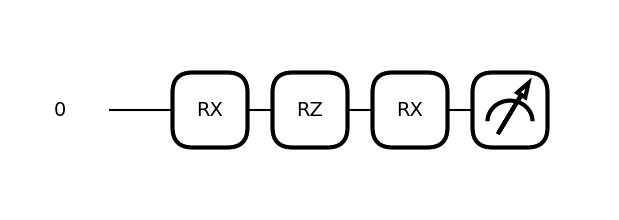

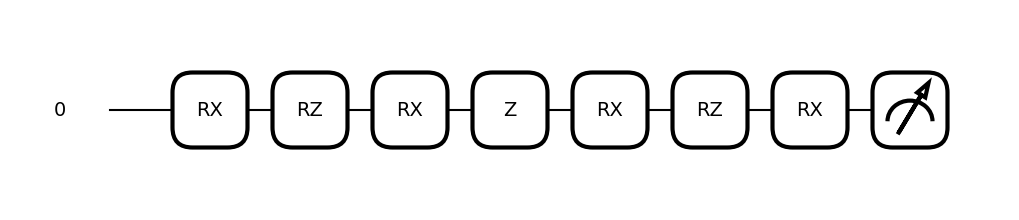

In [ ]:
import pennylane as qml
import numpy as np

dim_x = 1
dim_alpha = 1
observable_terms = ['Z0']

def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

dev = qml.device('default.qubit', wires=1)

@qml.qnode(dev)
def U(x, α):
    qml.RX(x[0], wires=0)
    qml.RZ(α[0], wires=0)
    qml.RX(x[0], wires=0)
    return qml.state()

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=0)
    qml.RZ(α[0], wires=0)
    qml.RX(x[0], wires=0)
    P = build_P(observable_terms)
    qml.RX(-x[0], wires=0)
    qml.RZ(-α[0], wires=0)
    qml.RX(-x[0], wires=0)
    return qml.state()

x0 = np.zeros(dim_x)
α0 = np.zeros(dim_alpha)
qml.draw_mpl(U)(x0, α0);
qml.draw_mpl(UPU)(x0, α0);


## dim_x = 1 part 2 output

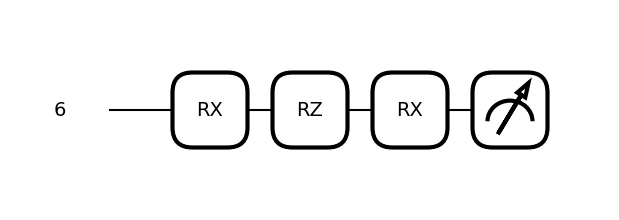

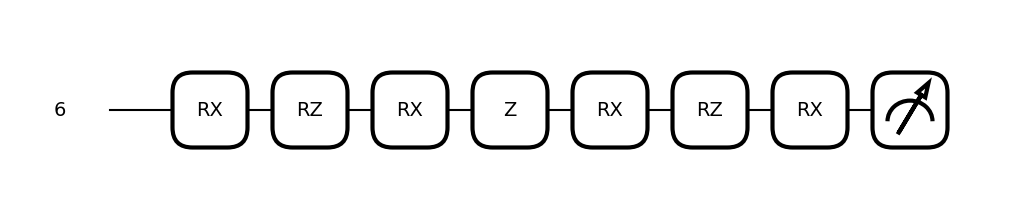

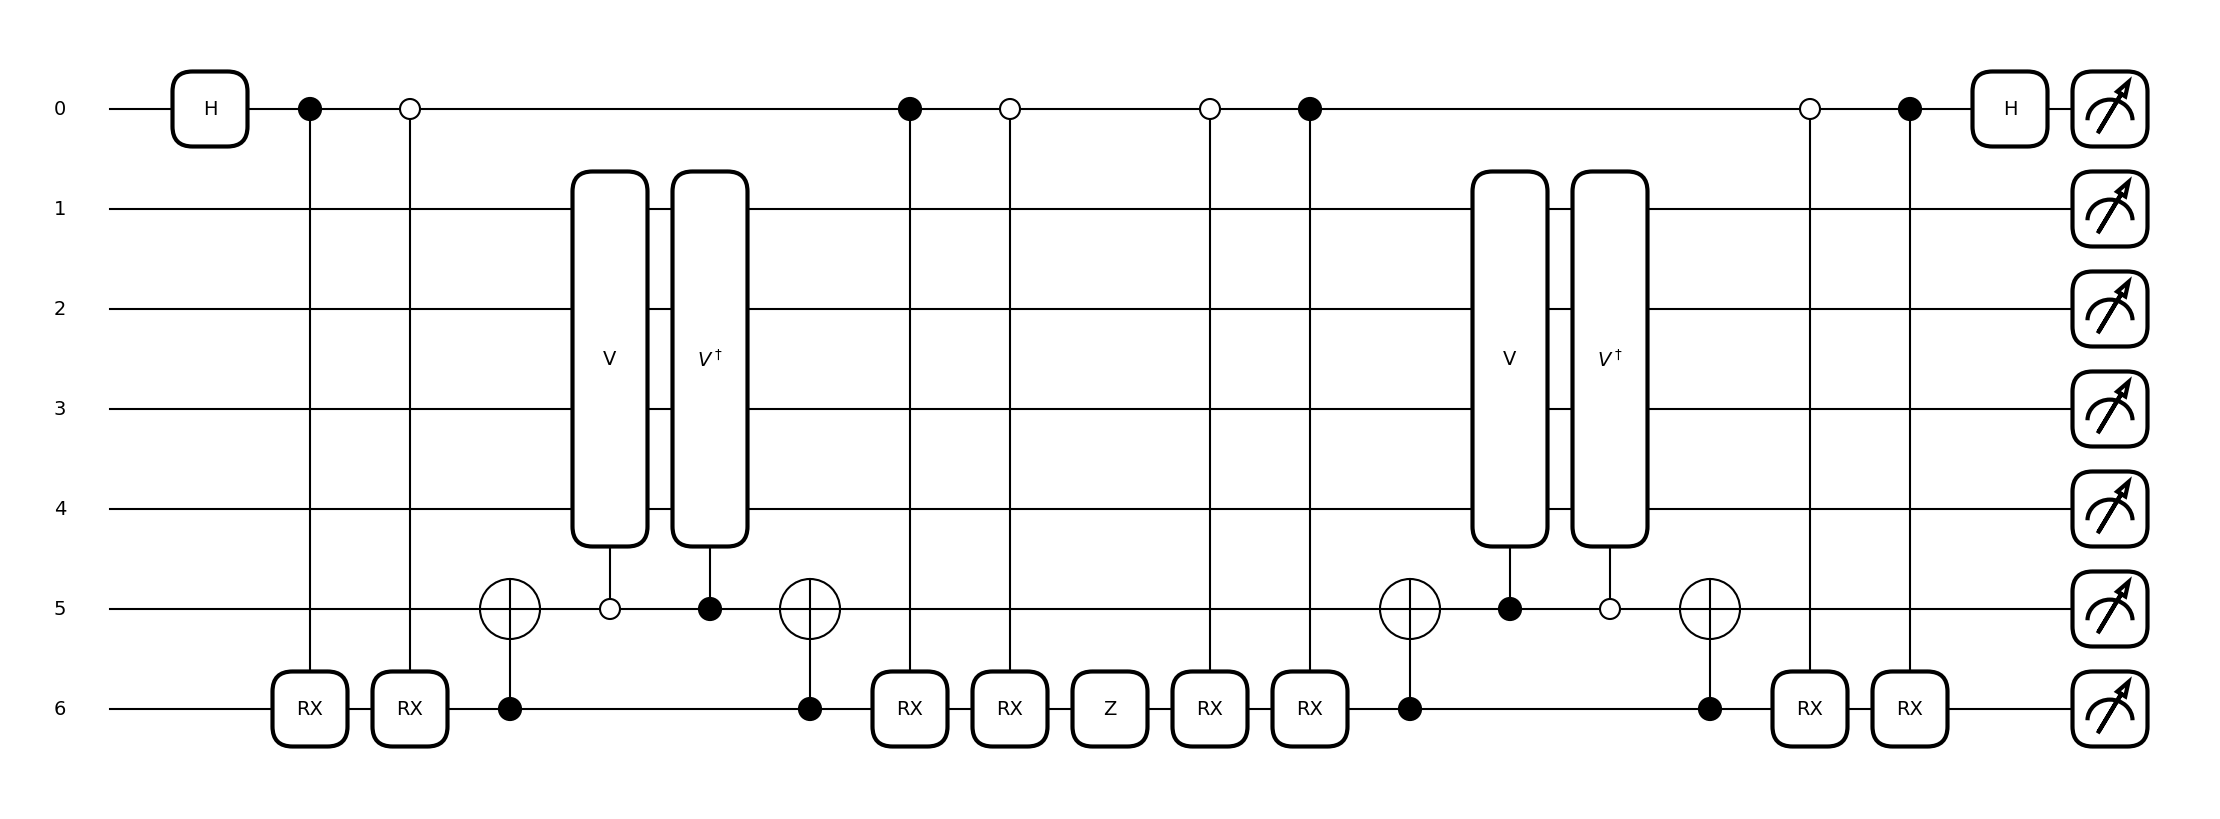

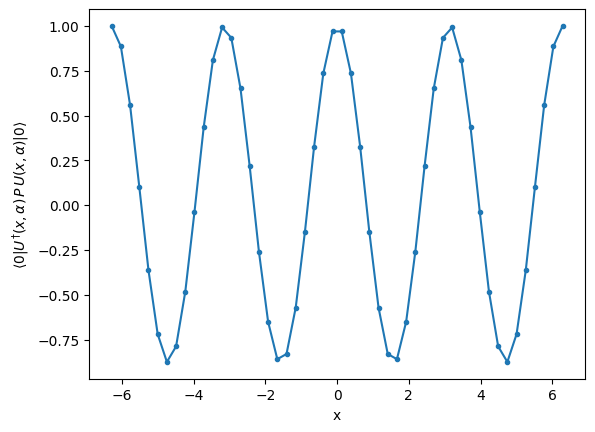

Computing train kernel: 100%|██████████| 40/40 [02:25<00:00,  3.63s/it]



Time to compute TRAIN kernel = 145.308 seconds



Computing test kernel: 100%|██████████| 10/10 [00:37<00:00,  3.73s/it]


Time to compute TEST kernel = 37.334 seconds

Time for Kernel Ridge Regression fit = 0.001 seconds

Train MSE = 0.00015033653887333622
Test MSE  = 0.004755999401332662
Train R2 = 0.9996426486020346
Test R2  = 0.9915728203647012

Train Kernel:
[[1.         0.4140363  1.         ... 0.97049073 0.5824101  0.99213517]
 [0.41278806 1.         0.41301296 ... 0.57104976 0.97193059 0.49022185]
 [1.         0.411744   1.         ... 0.97070779 0.58428    0.99215759]
 ...
 [0.9704136  0.56963054 0.96996727 ... 1.         0.73230299 0.99296564]
 [0.58435541 0.97089419 0.58239134 ... 0.73229241 1.         0.66099274]
 [0.99225177 0.490713   0.99206348 ... 0.99276382 0.65917093 1.        ]]
Train-Test Kernel:
[[0.9992611  0.43449678 0.99930912 0.33848279 0.77623605 0.02816278
  0.33581872 0.77621047 0.96085243 0.83767697 0.68708248 0.52141907
  0.99966286 0.83822659 0.03885571 0.99898904 0.14373749 0.88967007
  0.52161974 0.14440908 0.26366607 0.99600323 1.         0.99944468
  0.60533874 0.960927


c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


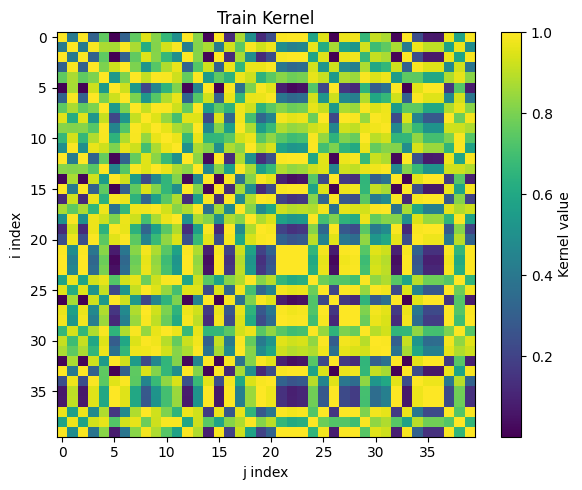

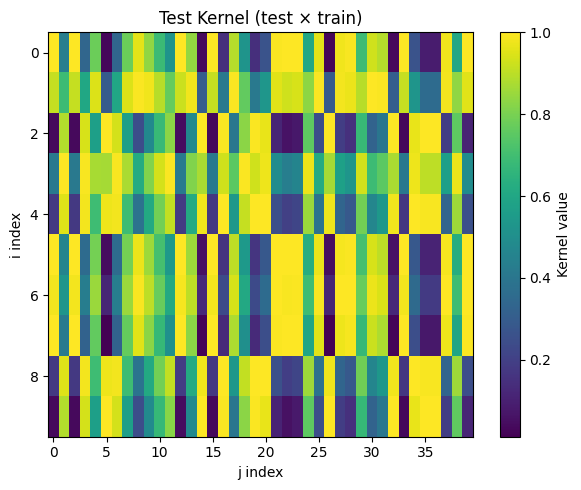

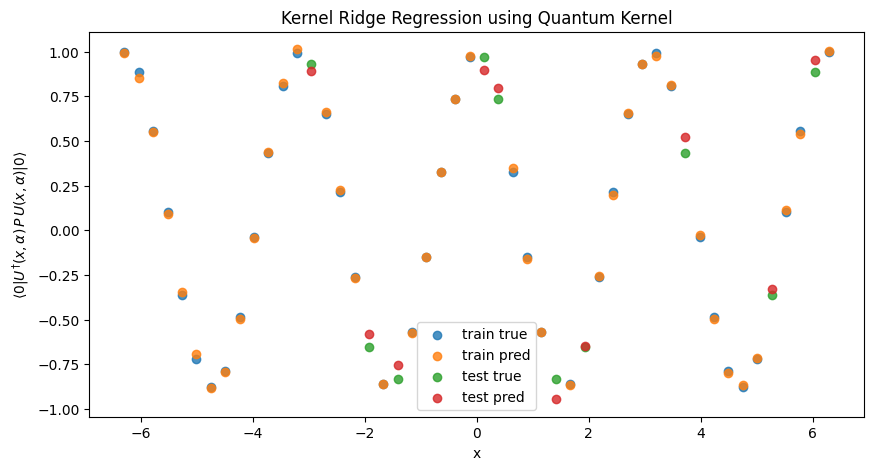

In [ ]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")



# -------------------------------------------------------
# KERNEL RIDGE REGRESSION
# -------------------------------------------------------
start_krr = time.time()
krr = KernelRidge(alpha=1e-3, kernel='precomputed')
krr.fit(K_train, Y_train)
end_krr = time.time()
print(f"Time for Kernel Ridge Regression fit = {end_krr - start_krr:.3f} seconds\n")

Y_train_pred = krr.predict(K_train)
Y_test_pred = krr.predict(K_test)

# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
print("Train MSE =", mean_squared_error(Y_train, Y_train_pred))
print("Test MSE  =", mean_squared_error(Y_test, Y_test_pred))

print("Train R2 =", r2_score(Y_train, Y_train_pred))
print("Test R2  =", r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

show_kernel_heatmap(K_train, "Train Kernel")
show_kernel_heatmap(K_test, "Test Kernel (test × train)")
# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()



# 20%

20% train 80 % test i.e., 10 training points and 40 testing points. \
Seed = 42

Outputs: \
Time to compute TEST kernel = 35.344 seconds \
Time for Kernel Ridge Regression fit = 0.098 seconds \
Train MSE = 5.23793260854929e-05 \
Test MSE  = 0.0006711319977689657 \
Train R2 = 0.9998886789991775 \
Test R2  = 0.9984833780358615

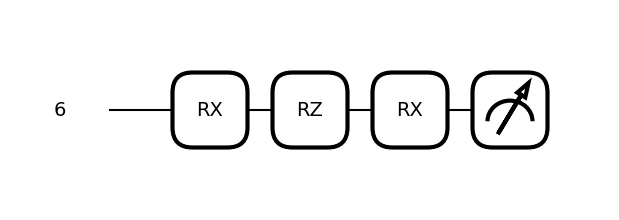

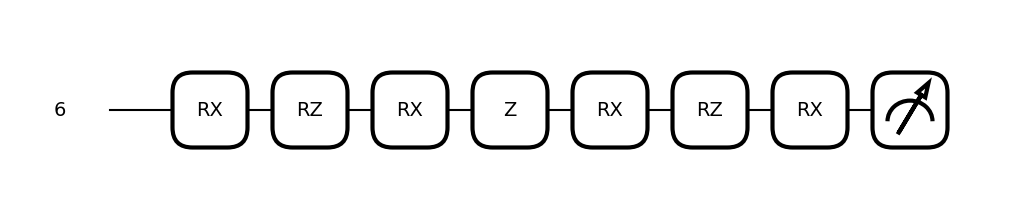

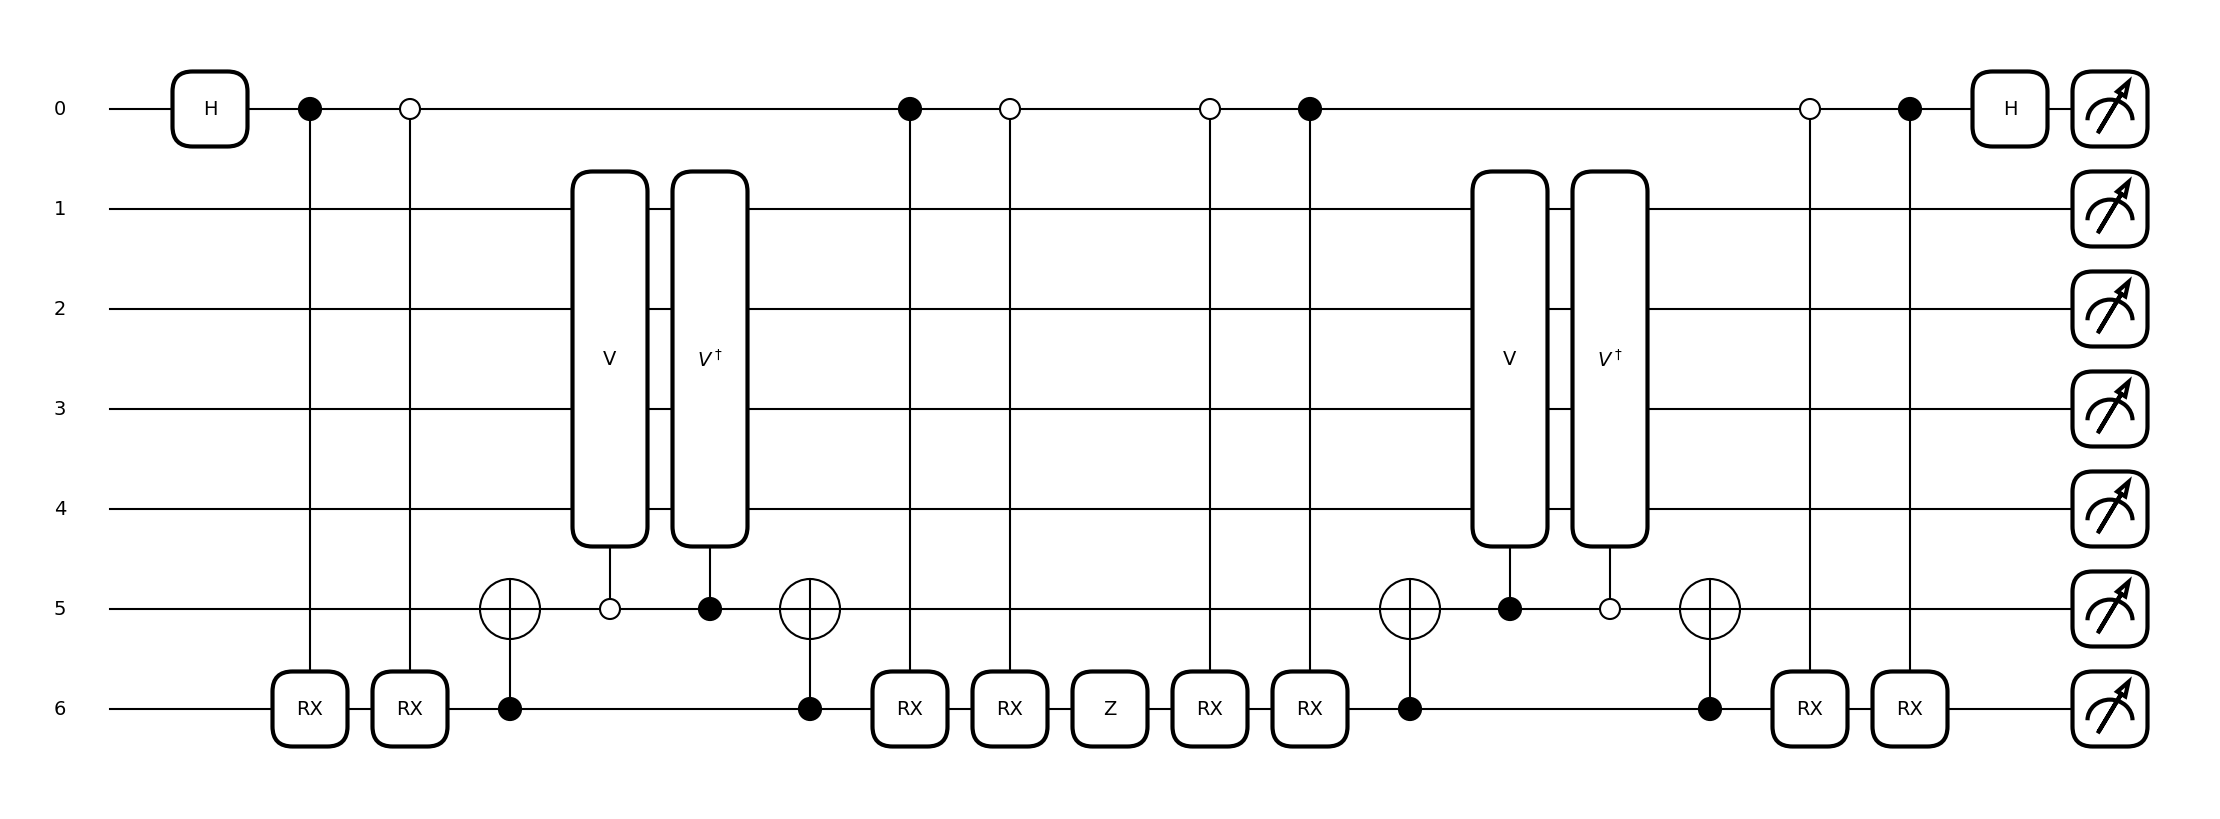

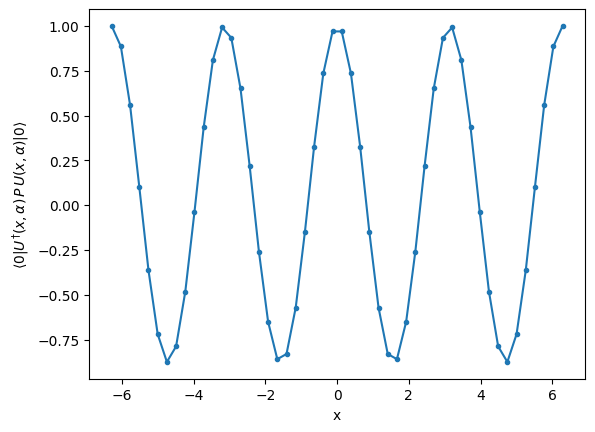

Computing train kernel: 100%|██████████| 10/10 [00:09<00:00,  1.09it/s]



Time to compute TRAIN kernel = 9.166 seconds



Computing test kernel: 100%|██████████| 40/40 [00:35<00:00,  1.13it/s]
c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(



Time to compute TEST kernel = 35.344 seconds

Time for Kernel Ridge Regression fit = 0.098 seconds

Train MSE = 5.23793260854929e-05
Test MSE  = 0.0006711319977689657
Train R2 = 0.9998886789991775
Test R2  = 0.9984833780358615

Train Kernel:
[[1.         0.9950576  0.30521628 0.91208421 0.52648011 0.35632003
  0.35772984 0.98380091 0.83423871 0.95587399]
 [0.99499936 1.         0.38120176 0.86906412 0.59777052 0.43236862
  0.43041794 0.96135703 0.88164499 0.922755  ]
 [0.30495758 0.37978288 1.         0.01380305 0.95915892 0.99787959
  0.99759893 0.16879967 0.74175034 0.089675  ]
 [0.91147316 0.86988414 0.01388762 1.         0.23594911 0.06497481
  0.06430809 0.96932192 0.57982872 0.99152164]
 [0.5265298  0.59733436 0.95924329 0.23573058 1.         0.97571568
  0.97611746 0.39960927 0.8935394  0.31737693]
 [0.35568919 0.43042945 0.99796027 0.06434052 0.97669822 1.
  1.         0.22287585 0.78223796 0.14180662]
 [0.35695029 0.42865424 0.99774017 0.06459684 0.97526498 1.
  1.         0.

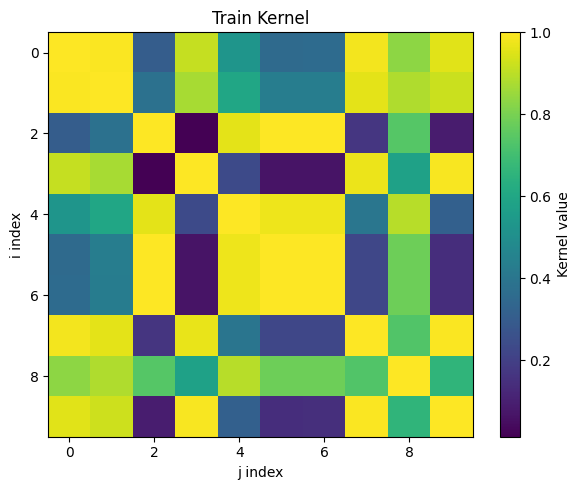

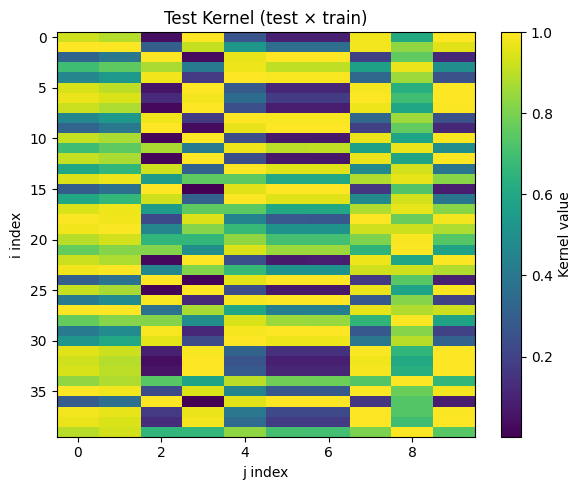

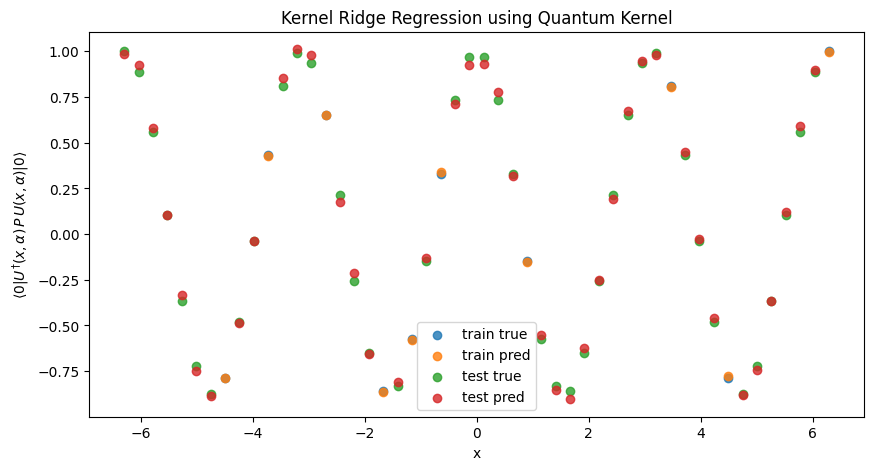

In [ ]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.8, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")



# -------------------------------------------------------
# KERNEL RIDGE REGRESSION
# -------------------------------------------------------
start_krr = time.time()
krr = KernelRidge(alpha=1e-3, kernel='precomputed')
krr.fit(K_train, Y_train)
end_krr = time.time()
print(f"Time for Kernel Ridge Regression fit = {end_krr - start_krr:.3f} seconds\n")

Y_train_pred = krr.predict(K_train)
Y_test_pred = krr.predict(K_test)

# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
print("Train MSE =", mean_squared_error(Y_train, Y_train_pred))
print("Test MSE  =", mean_squared_error(Y_test, Y_test_pred))

print("Train R2 =", r2_score(Y_train, Y_train_pred))
print("Test R2  =", r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

show_kernel_heatmap(K_train, "Train Kernel")
show_kernel_heatmap(K_test, "Test Kernel (test × train)")
# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()



# Varying Train Test Split

Single Seed = 42 \
Varied the train test split with the following % used for test and rest for train: \
0.98, 0.96, 0.94, 0.92, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10

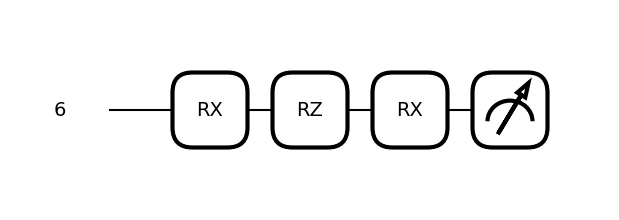

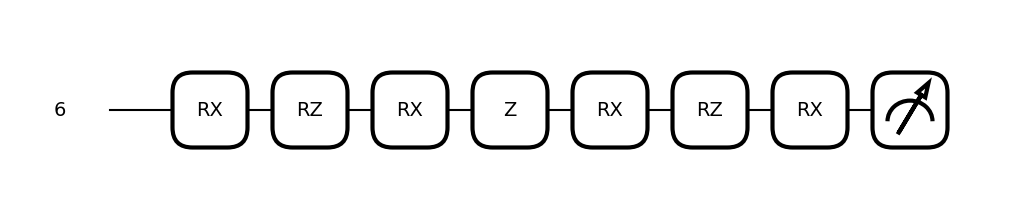

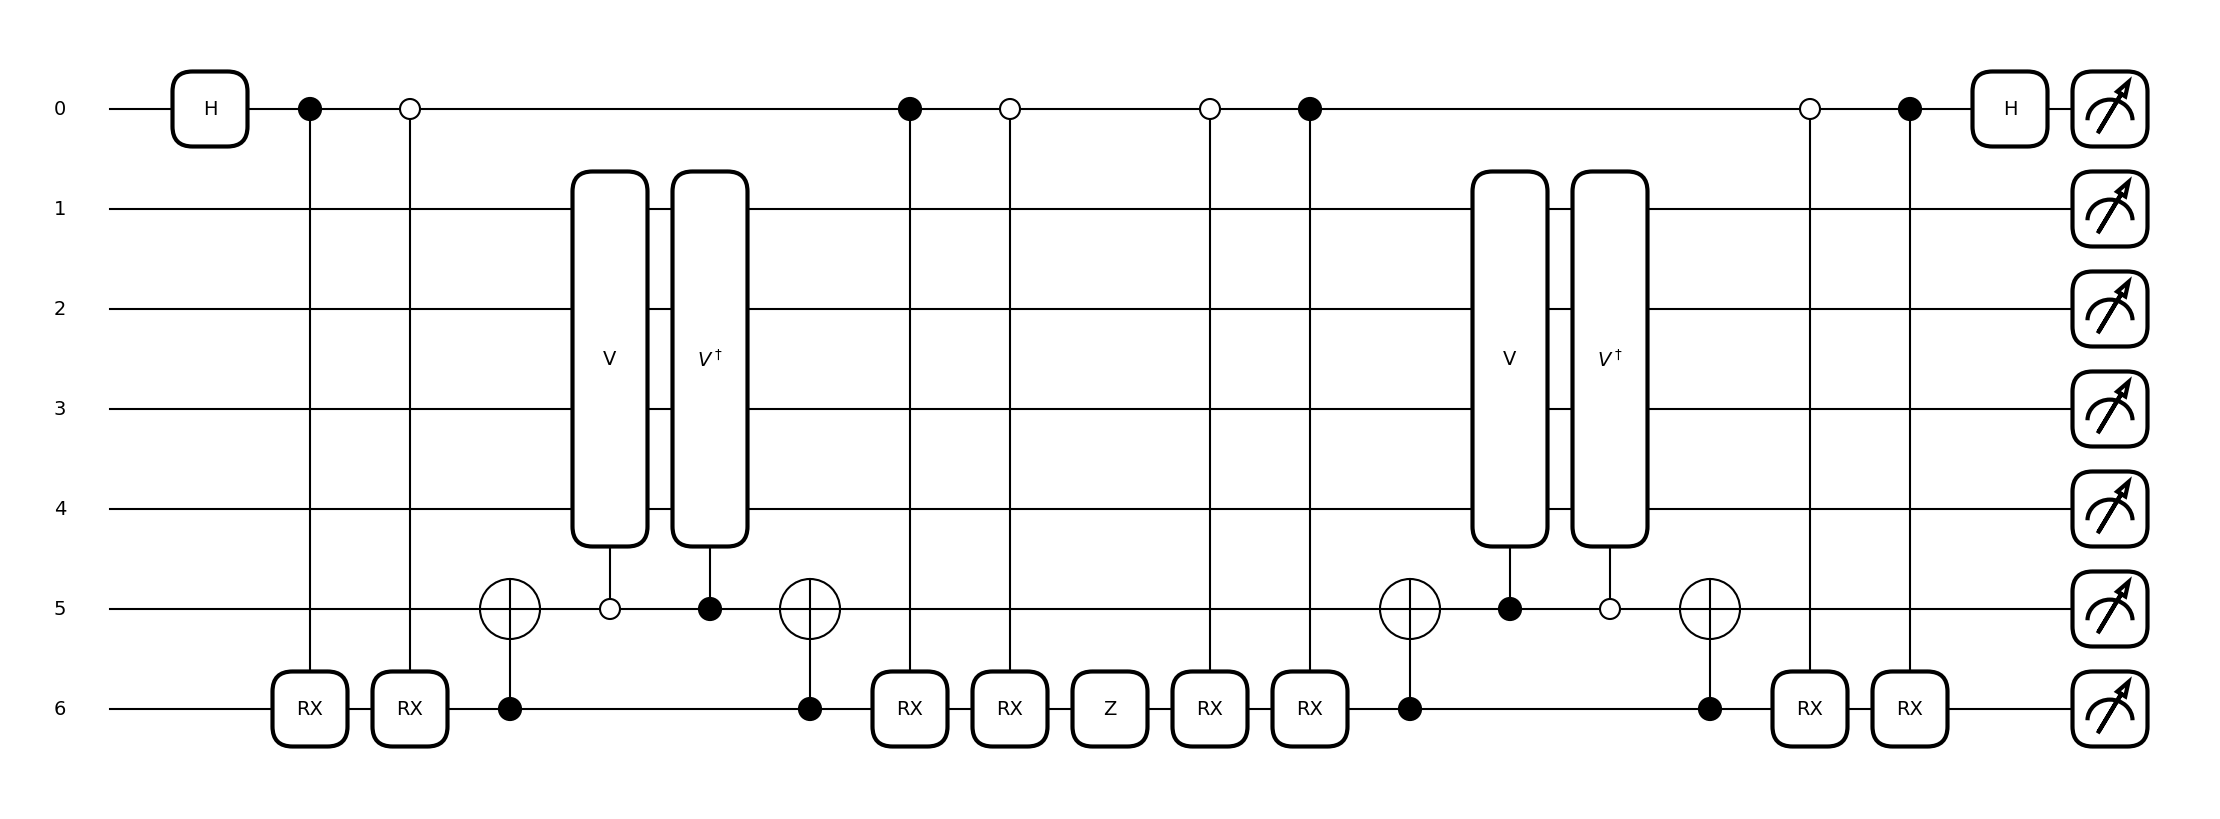

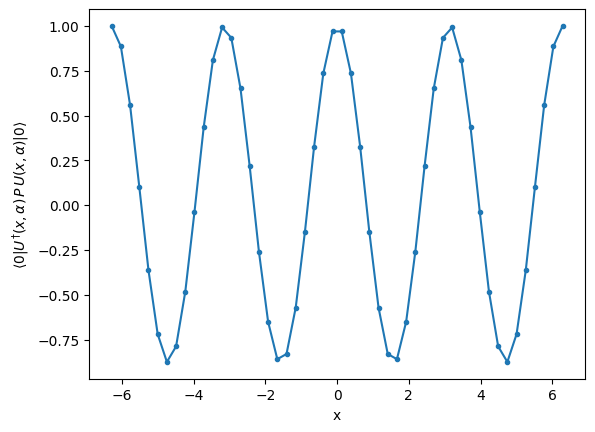

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]


=== Test ratio = 0.98 ===


Computing test kernel: 100%|██████████| 49/49 [00:04<00:00, 11.06it/s]
c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Sweeping test ratios:   8%|▊         | 1/13 [00:04<00:54,  4.55s/it]


=== Test ratio = 0.96 ===


Sweeping test ratios:  15%|█▌        | 2/13 [00:13<01:19,  7.26s/it]

...

Computing test kernel: 100%|██████████| 15/15 [02:52<00:00, 11.47s/it]
c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
Sweeping test ratios:  85%|████████▍ | 11/13 [23:12<10:12, 306.31s/it]


=== Test ratio = 0.2 ===


Computing test kernel: 100%|██████████| 10/10 [02:29<00:00, 14.93s/it]
c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
Sweeping test ratios:  92%|█████████▏| 12/13 [35:31<07:17, 437.89s/it]


=== Test ratio = 0.1 ===


Computing test kernel: 100%|██████████| 5/5 [01:18<00:00, 15.74s/it]
c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
Sweeping test ratios: 100%|██████████| 13/13 [48:06<00:00, 222.03s/it]


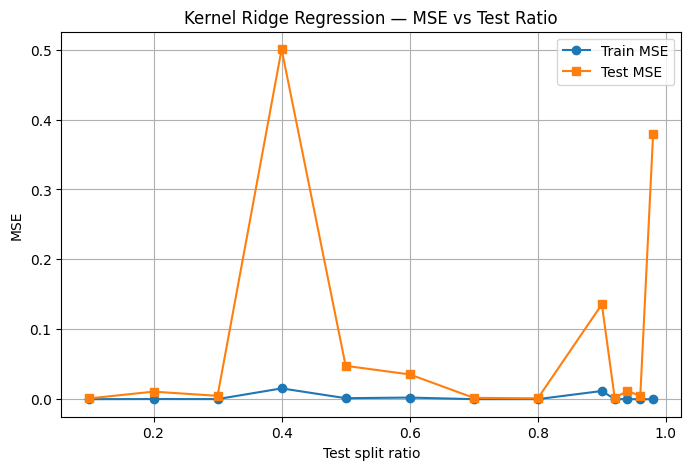

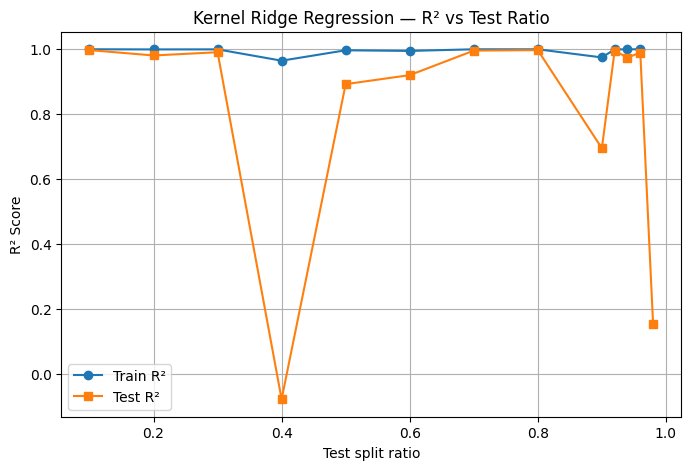

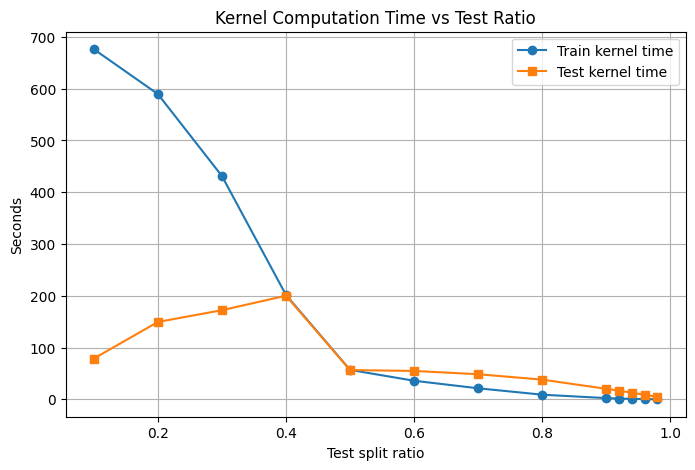

In [ ]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.8, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


test_ratios = [0.98, 0.96, 0.94, 0.92, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
mse_train_list = []
mse_test_list  = []
r2_train_list  = []
r2_test_list   = []

kernel_time_train = []
kernel_time_test  = []


for ratio in tqdm(test_ratios, desc="Sweeping test ratios"):
    print(f"\n=== Test ratio = {ratio} ===")

    # -------------------------
    # Train/test split
    # -------------------------
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=ratio, shuffle=True, random_state=SEED
    )

    # -------------------------
    # Compute TRAIN kernel with timing
    # -------------------------
    start = time.time()
    K_train = compute_kernel_matrix_train(X_train, alpha)
    end = time.time()
    kernel_time_train.append(end - start)

    # -------------------------
    # Compute TEST kernel with timing
    # -------------------------
    start = time.time()
    K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
    end = time.time()
    kernel_time_test.append(end - start)

    # -------------------------
    # Kernel Ridge Regression
    # -------------------------
    krr = KernelRidge(alpha=1e-3, kernel='precomputed')
    krr.fit(K_train, Y_train)

    Y_train_pred = krr.predict(K_train)
    Y_test_pred  = krr.predict(K_test)

    # -------------------------
    # Metrics
    # -------------------------
    mse_train_list.append(mean_squared_error(Y_train, Y_train_pred))
    mse_test_list.append(mean_squared_error(Y_test, Y_test_pred))

    r2_train_list.append(r2_score(Y_train, Y_train_pred))
    r2_test_list.append(r2_score(Y_test, Y_test_pred))


plt.figure(figsize=(8,5))
plt.plot(test_ratios, mse_train_list, "o-", label="Train MSE")
plt.plot(test_ratios, mse_test_list,  "s-", label="Test MSE")
plt.xlabel("Test split ratio")
plt.ylabel("MSE")
plt.title("Kernel Ridge Regression — MSE vs Test Ratio")
plt.legend()
plt.grid(True)
plt.show();

plt.figure(figsize=(8,5))
plt.plot(test_ratios, r2_train_list, "o-", label="Train R²")
plt.plot(test_ratios, r2_test_list,  "s-", label="Test R²")
plt.xlabel("Test split ratio")
plt.ylabel("R² Score")
plt.title("Kernel Ridge Regression — R² vs Test Ratio")
plt.legend()
plt.grid(True)
plt.show();

plt.figure(figsize=(8,5))
plt.plot(test_ratios, kernel_time_train, "o-", label="Train kernel time")
plt.plot(test_ratios, kernel_time_test,  "s-", label="Test kernel time")
plt.xlabel("Test split ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Time vs Test Ratio")
plt.legend()
plt.grid(True)
plt.show();





# Vary Seed and Train Test Split

Varied the seed with the following 10 values: \
42, 7, 123, 99, 2025, 0, 5, 88, 314, 256 \
Varied the train test split with the following % used for test and rest for train: \
0.98, 0.96, 0.94, 0.92, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10

## Main code

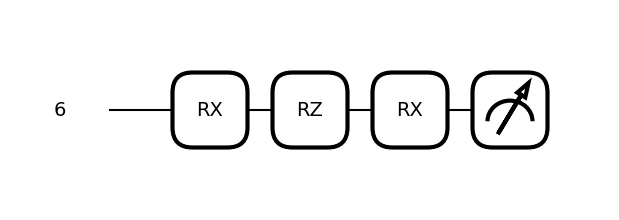

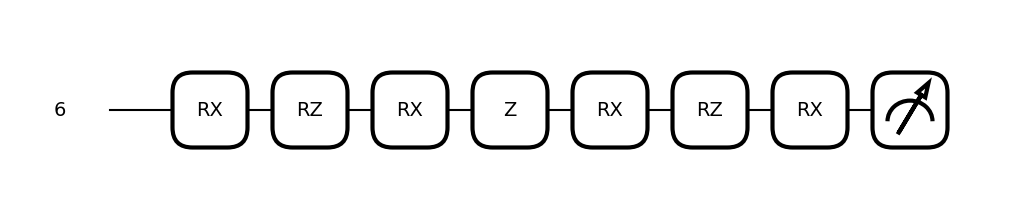

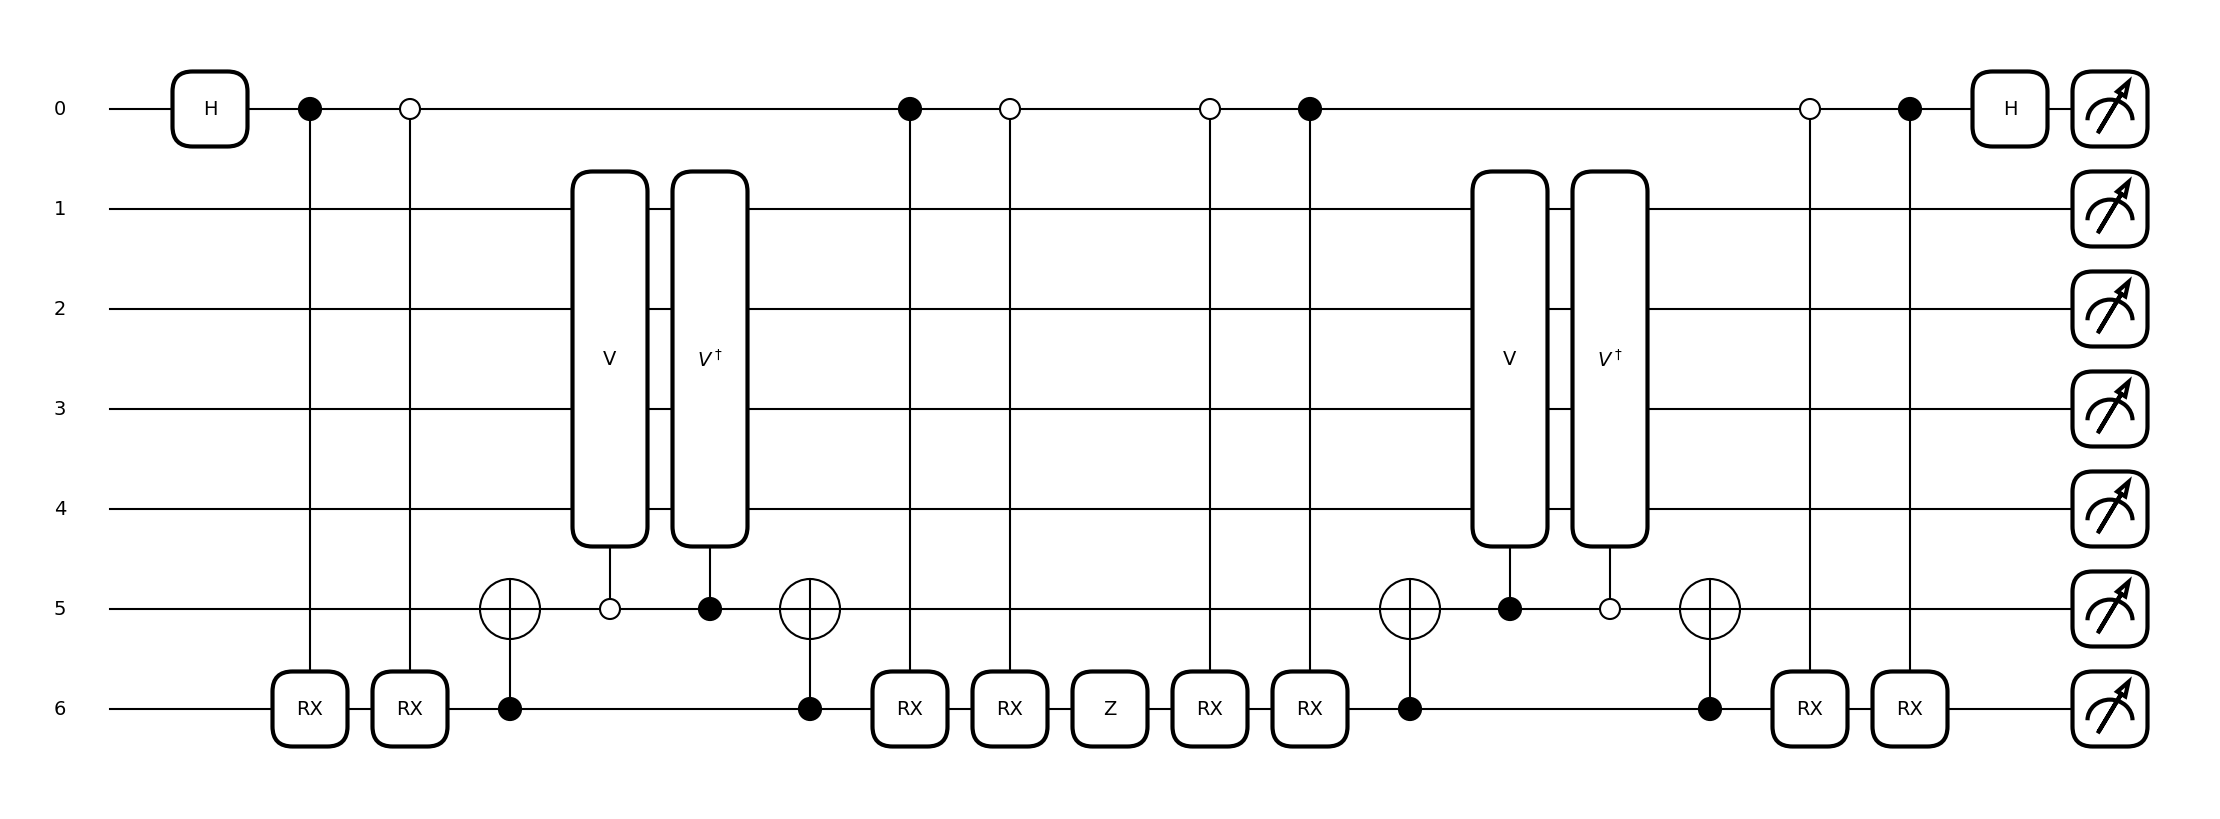

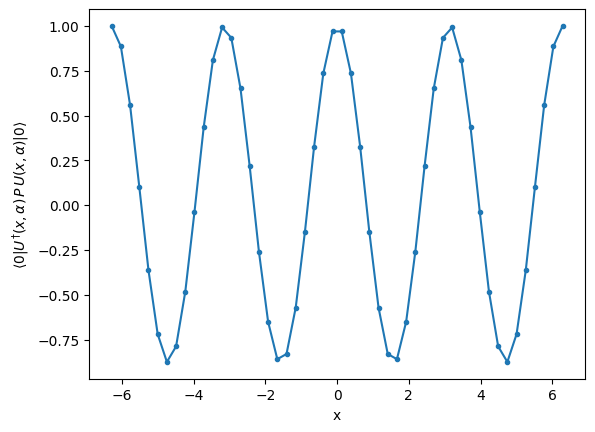

Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Computing train kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/49 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


...

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Computing train kernel:   0%|          | 0/45 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


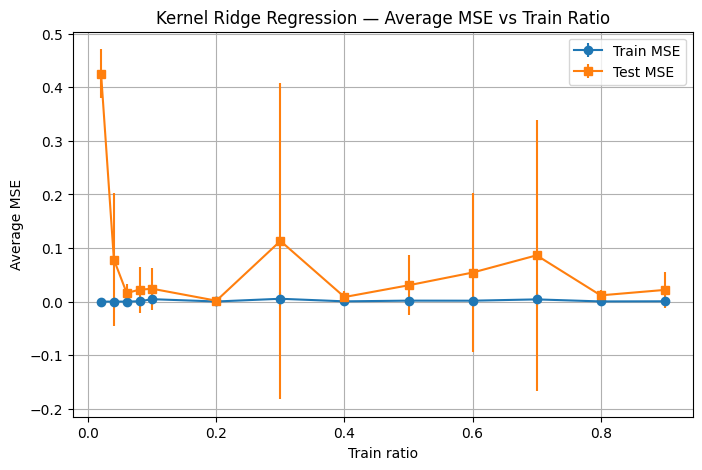

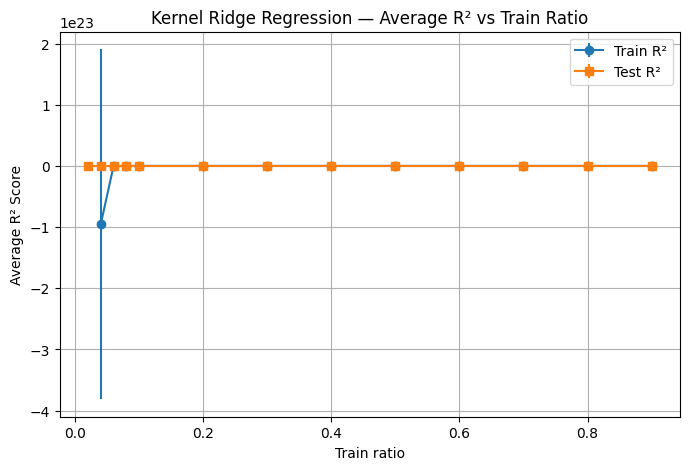

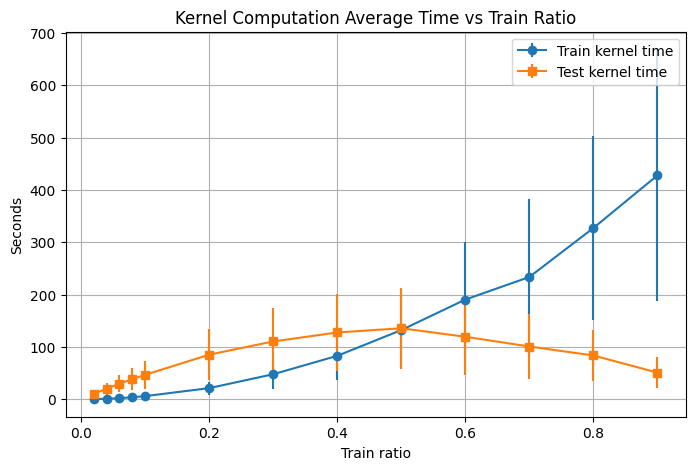


   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)

Train/Test Ratio = 0.98
  Avg Train MSE = 0.000001
  Avg Test  MSE = 0.424994
  Test/Train MSE Ratio = 833301.5011
----------------------------------------------
Train/Test Ratio = 0.96
  Avg Train MSE = 0.000019
  Avg Test  MSE = 0.078432
  Test/Train MSE Ratio = 4121.9959
----------------------------------------------
Train/Test Ratio = 0.94
  Avg Train MSE = 0.000038
  Avg Test  MSE = 0.016025
  Test/Train MSE Ratio = 424.0697
----------------------------------------------
Train/Test Ratio = 0.92
  Avg Train MSE = 0.000654
  Avg Test  MSE = 0.022252
  Test/Train MSE Ratio = 34.0279
----------------------------------------------
Train/Test Ratio = 0.9
  Avg Train MSE = 0.004522
  Avg Test  MSE = 0.023965
  Test/Train MSE Ratio = 5.2995
----------------------------------------------
Train/Test Ratio = 0.8
  Avg Train MSE = 0.000218
  Avg Test  MSE = 0.001677
  Test/Train MSE Ratio = 7.6942
----------------------------------------------
Tr

In [ ]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.8, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel", leave = False):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel", leave = False):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
test_ratios = [0.98, 0.96, 0.94, 0.92, 0.90,
               0.80, 0.70, 0.60, 0.50,
               0.40, 0.30, 0.20, 0.10]

n_seeds = 10
seeds = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]

# store shapes:
n_ratios = len(test_ratios)

mse_train_arr = np.zeros((n_seeds, n_ratios))
mse_test_arr  = np.zeros((n_seeds, n_ratios))
r2_train_arr  = np.zeros((n_seeds, n_ratios))
r2_test_arr   = np.zeros((n_seeds, n_ratios))

kernel_train_time_arr = np.zeros((n_seeds, n_ratios))
kernel_test_time_arr  = np.zeros((n_seeds, n_ratios))


# ---------------------------------------------------------
# MAIN SWEEP
# ---------------------------------------------------------
for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave = False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )

        # -------------------------
        # Compute TRAIN kernel (timed)
        # -------------------------
        start = time.time()
        K_train = compute_kernel_matrix_train(X_train, alpha)
        kernel_train_time_arr[s_idx, r_idx] = time.time() - start

        # -------------------------
        # Compute TEST kernel (timed)
        # -------------------------
        start = time.time()
        K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
        kernel_test_time_arr[s_idx, r_idx] = time.time() - start

        # -------------------------
        # Kernel Ridge Regression
        # -------------------------
        krr = KernelRidge(alpha=1e-3, kernel='precomputed')
        krr.fit(K_train, Y_train)

        Y_train_pred = krr.predict(K_train)
        Y_test_pred  = krr.predict(K_test)

        # -------------------------
        # Metrics
        # -------------------------
        mse_train_arr[s_idx, r_idx] = mean_squared_error(Y_train, Y_train_pred)
        mse_test_arr[s_idx, r_idx]  = mean_squared_error(Y_test, Y_test_pred)

        r2_train_arr[s_idx, r_idx]  = r2_score(Y_train, Y_train_pred)
        r2_test_arr[s_idx, r_idx]   = r2_score(Y_test, Y_test_pred)


# ---------------------------------------------------------
# COMPUTE MEANS + STANDARD DEVIATION
# ---------------------------------------------------------

train_ratios = [1 - r for r in test_ratios]

mse_train_mean = mse_train_arr.mean(axis=0)
mse_test_mean  = mse_test_arr.mean(axis=0)
mse_train_std  = mse_train_arr.std(axis=0)
mse_test_std   = mse_test_arr.std(axis=0)

r2_train_mean = r2_train_arr.mean(axis=0)
r2_test_mean  = r2_test_arr.mean(axis=0)
r2_train_std  = r2_train_arr.std(axis=0)
r2_test_std   = r2_test_arr.std(axis=0)

kernel_train_mean = kernel_train_time_arr.mean(axis=0)
kernel_test_mean  = kernel_test_time_arr.mean(axis=0)
kernel_train_std  = kernel_train_time_arr.std(axis=0)
kernel_test_std   = kernel_test_time_arr.std(axis=0)


# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE")
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²")
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²")
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time")
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time")
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# PER-RATIO SUMMARY STATISTICS (AVERAGED OVER SEEDS)
# ---------------------------------------------------------
print("\n==============================================")
print("   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)")
print("==============================================\n")

for r_idx, ratio in enumerate(test_ratios):

    avg_train_mse = mse_train_arr[:, r_idx].mean()
    avg_test_mse  = mse_test_arr[:, r_idx].mean()
    ratio_val = avg_test_mse / avg_train_mse if avg_train_mse > 0 else np.nan

    print(f"Train/Test Ratio = {ratio}")
    print(f"  Avg Train MSE = {avg_train_mse:.6f}")
    print(f"  Avg Test  MSE = {avg_test_mse:.6f}")
    print(f"  Test/Train MSE Ratio = {ratio_val:.4f}")
    print("----------------------------------------------")



## Main Plots with error bars

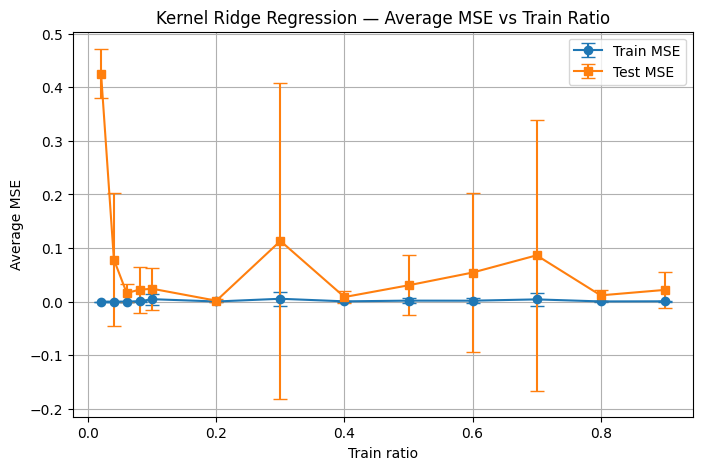

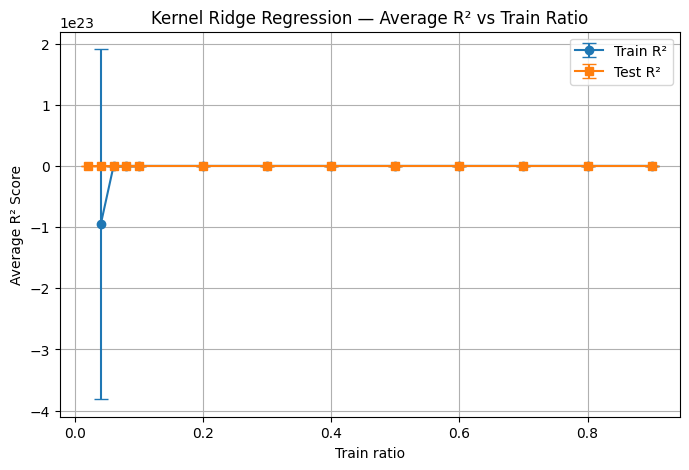

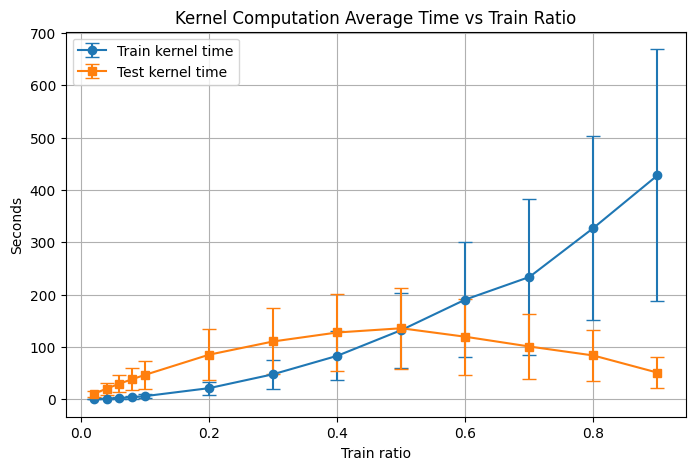

In [ ]:

# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE", capsize=5)
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²",capsize=5)
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time",capsize=5)
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## MSE plot without error bars

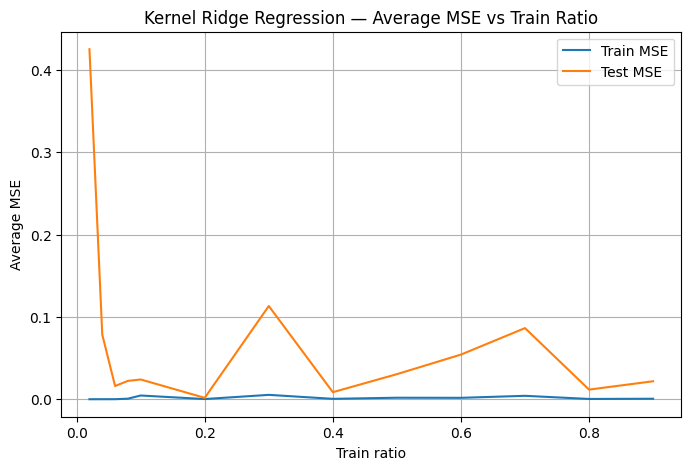

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_ratios, mse_train_mean,   label="Train MSE")
plt.plot(train_ratios, mse_test_mean,    label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

## MSE plots with y limited to 0.1

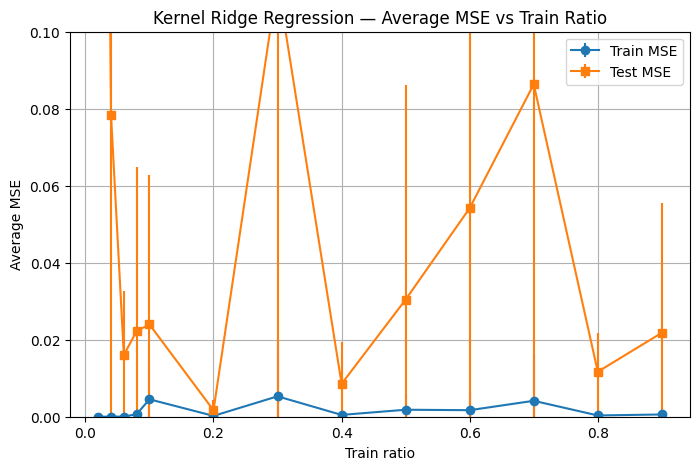

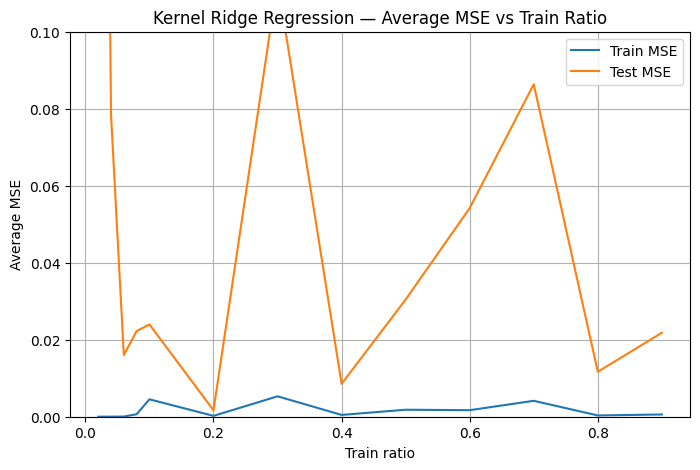

In [ ]:

# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE")
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.ylim(0,0.1)
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_ratios, mse_train_mean,   label="Train MSE")
plt.plot(train_ratios, mse_test_mean,    label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.ylim(0,0.1)
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## MSE Data per train test ratio

In [ ]:

# ---------------------------------------------------------
# PER-RATIO SUMMARY STATISTICS (AVERAGED OVER SEEDS)
# ---------------------------------------------------------
print("\n==============================================")
print("   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)")
print("==============================================\n")

ratio_vals = []
for r_idx, ratio in enumerate(train_ratios):

    avg_train_mse = mse_train_arr[:, r_idx].mean()
    avg_test_mse  = mse_test_arr[:, r_idx].mean()
    ratio_val = avg_test_mse / avg_train_mse if avg_train_mse > 0 else np.nan
    ratio_vals.append(ratio_val)
    print(f"Train Ratio = {ratio}")
    print(f"  Avg Train MSE = {avg_train_mse:.6e}")
    print(f"  Avg Test  MSE = {avg_test_mse:.6e}")
    print(f"  Test/Train MSE Ratio = {ratio_val:.4e}")
    print("----------------------------------------------")




   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)

Train Ratio = 0.020000000000000018
  Avg Train MSE = 5.100123e-07
  Avg Test  MSE = 4.249940e-01
  Test/Train MSE Ratio = 8.3330e+05
----------------------------------------------
Train Ratio = 0.040000000000000036
  Avg Train MSE = 1.902767e-05
  Avg Test  MSE = 7.843196e-02
  Test/Train MSE Ratio = 4.1220e+03
----------------------------------------------
Train Ratio = 0.06000000000000005
  Avg Train MSE = 3.778825e-05
  Avg Test  MSE = 1.602485e-02
  Test/Train MSE Ratio = 4.2407e+02
----------------------------------------------
Train Ratio = 0.07999999999999996
  Avg Train MSE = 6.539386e-04
  Avg Test  MSE = 2.225215e-02
  Test/Train MSE Ratio = 3.4028e+01
----------------------------------------------
Train Ratio = 0.09999999999999998
  Avg Train MSE = 4.522067e-03
  Avg Test  MSE = 2.396462e-02
  Test/Train MSE Ratio = 5.2995e+00
----------------------------------------------
Train Ratio = 0.19999999999999996
  Avg Train MSE = 2.17

## Ratio of test to train error plot

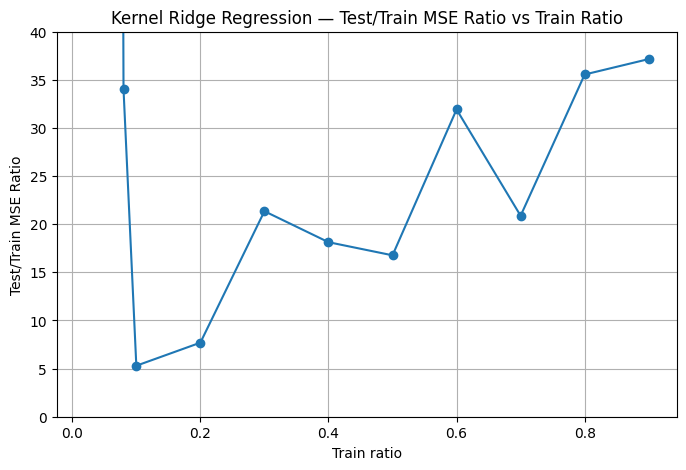

In [ ]:
plt.figure(figsize=(8,5))
# plot ratio values vs train ratio
plt.plot(train_ratios, ratio_vals, "o-")
plt.xlabel("Train ratio")
plt.ylabel("Test/Train MSE Ratio")
plt.title("Kernel Ridge Regression — Test/Train MSE Ratio vs Train Ratio")
plt.ylim(0,40)
plt.grid(True)
plt.show()

## Plots for R2 and time

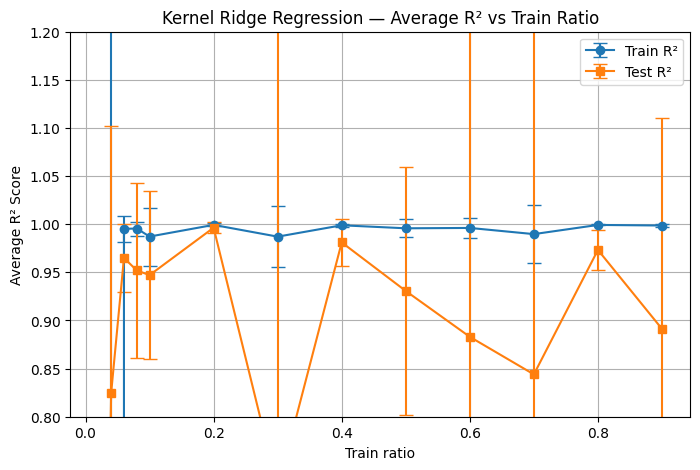

In [ ]:
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²",capsize=5)
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.ylim(0.8,1.2)
plt.legend()
plt.grid(True)
plt.show()


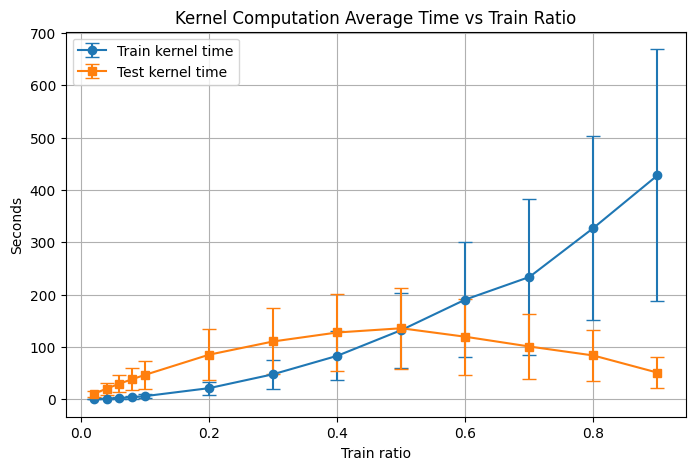

In [ ]:

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time",capsize=5)
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

## Printing data if needed later

In [ ]:
print(test_ratios)
print(train_ratios)

[0.98, 0.96, 0.94, 0.92, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
[0.020000000000000018, 0.040000000000000036, 0.06000000000000005, 0.07999999999999996, 0.09999999999999998, 0.19999999999999996, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [ ]:

print(mse_train_arr)
print(mse_test_arr)


[[6.53708195e-07 1.19667434e-06 7.39638856e-05 2.16688056e-04
  1.17717989e-02 1.24640358e-04 1.02920322e-04 2.35483705e-03
  1.48423017e-03 1.54941187e-02 1.72326738e-04 2.52607126e-04
  7.09818344e-05]
 [3.10609945e-07 4.94843640e-06 4.78563335e-05 1.17115417e-04
  4.60509624e-05 7.95916696e-05 3.98989159e-03 5.05455336e-04
  9.31801551e-05 2.26903438e-04 2.98927189e-05 7.16181715e-04
  1.55523983e-03]
 [1.31867006e-07 6.07425388e-06 8.51188415e-06 1.49056230e-03
  1.36229422e-04 1.65535522e-03 3.67003807e-04 1.04974524e-03
  3.02383251e-05 6.53038768e-04 9.95918490e-05 5.15018515e-04
  2.33938426e-04]
 [7.81921609e-07 4.13240998e-05 7.56576570e-05 3.93387078e-03
  5.82378763e-05 5.91746308e-05 1.64278467e-05 1.25390748e-05
  1.37068285e-02 1.07355406e-04 4.16309551e-05 2.32001164e-04
  7.86143436e-05]
 [6.88613933e-07 1.13559268e-04 6.64674113e-06 2.01107228e-06
  2.69593323e-05 2.71165484e-05 1.57234016e-04 1.86496860e-04
  4.19002208e-05 2.79024761e-05 8.41089766e-05 7.76358650e-0

In [ ]:

print(r2_train_arr)
print(r2_test_arr)


[[            nan  9.99994793e-01  9.99579987e-01  9.99476141e-01
   9.74741953e-01  9.99735104e-01  9.99768466e-01  9.94741518e-01
   9.96728116e-01  9.64719341e-01  9.99588087e-01  9.99399550e-01
   9.99840625e-01]
 [            nan  9.99976684e-01  9.99845863e-01  9.99528002e-01
   9.99887425e-01  9.99777943e-01  9.90974829e-01  9.98911942e-01
   9.99818608e-01  9.99538170e-01  9.99934942e-01  9.98414617e-01
   9.96513952e-01]
 [            nan  9.99971380e-01  9.99945088e-01  9.87962902e-01
   9.99274058e-01  9.94386543e-01  9.99015409e-01  9.97325925e-01
   9.99924441e-01  9.98418454e-01  9.99777951e-01  9.98821183e-01
   9.99470961e-01]
 [            nan  9.96989838e-01  9.99505981e-01  9.76703181e-01
   9.99586992e-01  9.99856454e-01  9.99959016e-01  9.99972195e-01
   9.68639673e-01  9.99769243e-01  9.99906875e-01  9.99497613e-01
   9.99827531e-01]
 [            nan  4.58318315e-01  9.99991215e-01  9.99997626e-01
   9.99960233e-01  9.99951791e-01  9.99666143e-01  9.99593917e-01


In [ ]:

print(kernel_train_time_arr)
print(kernel_test_time_arr)

[[1.12897873e-01 3.90375376e-01 8.02282810e-01 1.46610689e+00
  2.33820820e+00 9.12963843e+00 2.01375096e+01 3.63343272e+01
  5.96573057e+01 8.29241419e+01 1.13356021e+02 1.88156881e+02
  1.85291494e+02]
 [1.05992079e-01 3.81917477e-01 7.75346041e-01 1.50615072e+00
  2.25755692e+00 8.91749835e+00 2.03482566e+01 3.52344043e+01
  5.99547458e+01 8.14260187e+01 1.10187466e+02 1.49322899e+02
  1.90124601e+02]
 [1.18837833e-01 3.90630007e-01 8.55319977e-01 1.48515081e+00
  2.29464841e+00 9.04140377e+00 2.05335410e+01 3.62255151e+01
  6.06677713e+01 8.13933458e+01 1.11848061e+02 1.46793993e+02
  1.89571752e+02]
 [9.49943066e-02 3.61580372e-01 8.16650391e-01 1.55549216e+00
  2.27385473e+00 8.97255421e+00 2.03749714e+01 3.60000644e+01
  6.06980498e+01 8.13242991e+01 1.13311998e+02 1.47497056e+02
  1.86433192e+02]
 [1.17255688e-01 4.35013533e-01 8.93409491e-01 1.47815585e+00
  2.29857039e+00 8.90599036e+00 2.04833367e+01 3.59248452e+01
  6.20590630e+01 8.01957393e+01 1.10962863e+02 4.14181976e+0

## Nicer looking error plots

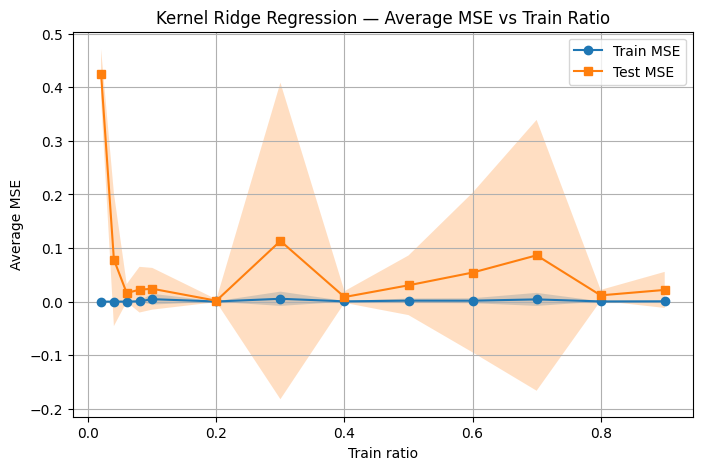

In [ ]:
plt.figure(figsize=(8,5))

# Train MSE
plt.plot(train_ratios, mse_train_mean, "o-", label="Train MSE")
plt.fill_between(train_ratios,
                 mse_train_mean - mse_train_std,
                 mse_train_mean + mse_train_std,
                 alpha=0.25)

# Test MSE
plt.plot(train_ratios, mse_test_mean, "s-", label="Test MSE")
plt.fill_between(train_ratios,
                 mse_test_mean - mse_test_std,
                 mse_test_mean + mse_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


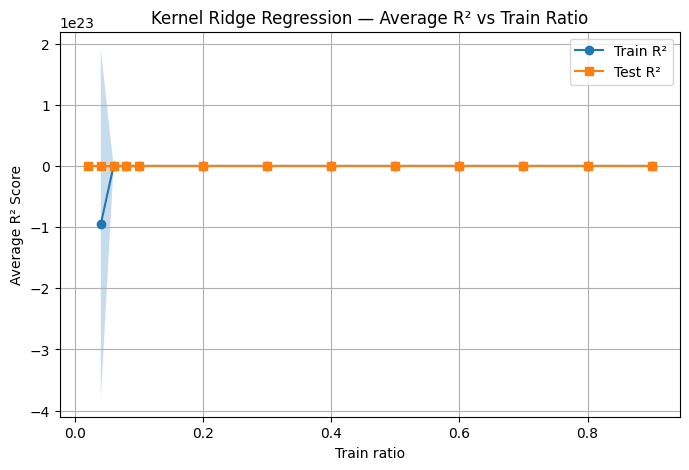

In [ ]:
plt.figure(figsize=(8,5))

# Train R2
plt.plot(train_ratios, r2_train_mean, "o-", label="Train R²")
plt.fill_between(train_ratios,
                 r2_train_mean - r2_train_std,
                 r2_train_mean + r2_train_std,
                 alpha=0.25)

# Test R2
plt.plot(train_ratios, r2_test_mean, "s-", label="Test R²")
plt.fill_between(train_ratios,
                 r2_test_mean - r2_test_std,
                 r2_test_mean + r2_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


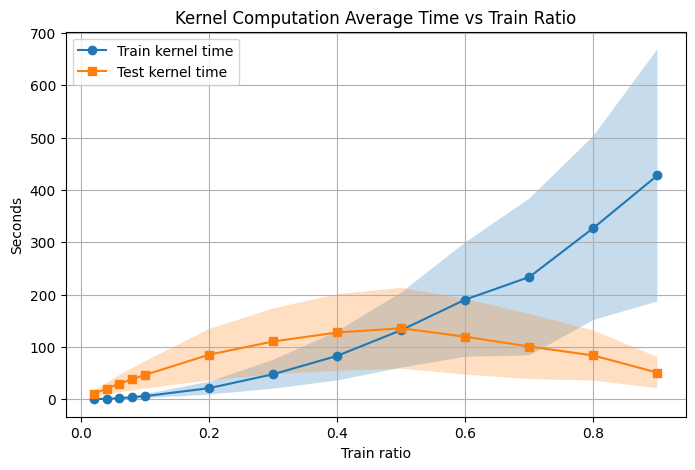

In [ ]:
plt.figure(figsize=(8,5))

# Train kernel time
plt.plot(train_ratios, kernel_train_mean, "o-", label="Train kernel time")
plt.fill_between(train_ratios,
                 kernel_train_mean - kernel_train_std,
                 kernel_train_mean + kernel_train_std,
                 alpha=0.25)

# Test kernel time
plt.plot(train_ratios, kernel_test_mean, "s-", label="Test kernel time")
plt.fill_between(train_ratios,
                 kernel_test_mean - kernel_test_std,
                 kernel_test_mean + kernel_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## Printing more data if needed later 

In [ ]:
for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave = False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )
        print(f"Seed = {seed}")
        print(f"Ratio = {ratio}")
        print(f"Train Data = {X_train}")
        print(f"Test Data = {X_test}")
        print(f"Train Labels = {Y_train}")
        print(f"Test Labels = {Y_test}")
        print("----------------------------------------------")

Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 42
Ratio = 0.98
Train Data = [array([3.46591837])]
Test Data = [array([-2.95244898]), array([3.72265306]), array([1.41204082]), array([5.26306122]), array([-1.9255102]), array([6.03326531]), array([0.38510204]), array([0.12836735]), array([1.9255102]), array([-1.41204082]), array([-3.20918367]), array([-5.26306122]), array([3.20918367]), array([-4.23612245]), array([-5.51979592]), array([-4.74959184]), array([4.23612245]), array([5.51979592]), array([5.77653061]), array([-2.43897959]), array([-3.97938776]), array([-2.1822449]), array([-0.12836735]), array([2.43897959]), array([1.66877551]), array([-6.29]), array([5.00632653]), array([0.64183673]), array([2.1822449]), array([-5.00632653]), array([1.15530612]), array([-3.46591837]), array([2.95244898]), array([-6.03326531]), array([-0.89857143]), array([-5.77653061]), array([4.74959184]), array([2.69571429]), array([-0.38510204]), array([3.97938776]), array([-3.72265306]), array([-0.64183673]), array([-1.66877551]), array([6.29]),

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 7
Ratio = 0.98
Train Data = [array([5.77653061])]
Test Data = [array([-2.95244898]), array([-2.43897959]), array([-0.64183673]), array([4.49285714]), array([1.41204082]), array([0.64183673]), array([-6.03326531]), array([-1.15530612]), array([-3.72265306]), array([2.95244898]), array([1.9255102]), array([5.51979592]), array([2.43897959]), array([-1.66877551]), array([-1.9255102]), array([2.69571429]), array([1.15530612]), array([4.23612245]), array([-3.97938776]), array([-5.77653061]), array([2.1822449]), array([-2.1822449]), array([-0.89857143]), array([1.66877551]), array([3.46591837]), array([-0.12836735]), array([-5.00632653]), array([-3.20918367]), array([5.26306122]), array([-4.74959184]), array([3.20918367]), array([3.97938776]), array([-3.46591837]), array([-6.29]), array([-4.49285714]), array([6.03326531]), array([4.74959184]), array([0.38510204]), array([6.29]), array([-4.23612245]), array([5.00632653]), array([-2.69571429]), array([0.89857143]), array([3.72265306]), a

...

Seed = 88
Ratio = 0.98
Train Data = [array([-0.12836735])]
Test Data = [array([3.46591837]), array([-5.77653061]), array([6.29]), array([-1.9255102]), array([2.95244898]), array([-1.41204082]), array([1.66877551]), array([5.26306122]), array([5.77653061]), array([0.64183673]), array([-0.89857143]), array([6.03326531]), array([-3.97938776]), array([0.89857143]), array([-1.66877551]), array([4.23612245]), array([5.51979592]), array([-6.29]), array([2.69571429]), array([3.97938776]), array([3.72265306]), array([-0.38510204]), array([-3.20918367]), array([-2.69571429]), array([-4.23612245]), array([-2.1822449]), array([-6.03326531]), array([1.41204082]), array([-5.51979592]), array([-2.95244898]), array([1.15530612]), array([-0.64183673]), array([-3.72265306]), array([-4.74959184]), array([5.00632653]), array([0.12836735]), array([0.38510204]), array([-4.49285714]), array([-5.26306122]), array([-3.46591837]), array([4.74959184]), array([2.43897959]), array([-5.00632653]), array([2.1822449]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 314
Ratio = 0.98
Train Data = [array([-4.23612245])]
Test Data = [array([2.1822449]), array([-3.20918367]), array([-1.9255102]), array([-3.72265306]), array([0.38510204]), array([-6.03326531]), array([5.00632653]), array([-1.41204082]), array([-3.46591837]), array([-0.38510204]), array([-4.74959184]), array([-5.00632653]), array([-1.66877551]), array([0.12836735]), array([0.89857143]), array([-1.15530612]), array([-0.89857143]), array([-6.29]), array([1.15530612]), array([1.66877551]), array([-5.51979592]), array([2.95244898]), array([-5.77653061]), array([1.41204082]), array([3.20918367]), array([5.77653061]), array([-2.43897959]), array([3.72265306]), array([3.46591837]), array([6.29]), array([-2.95244898]), array([6.03326531]), array([0.64183673]), array([1.9255102]), array([-5.26306122]), array([-0.12836735]), array([3.97938776]), array([4.23612245]), array([2.69571429]), array([-2.1822449]), array([4.74959184]), array([5.51979592]), array([2.43897959]), array([-4.49285714])

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 256
Ratio = 0.98
Train Data = [array([1.9255102])]
Test Data = [array([-1.66877551]), array([1.66877551]), array([0.38510204]), array([5.26306122]), array([-1.9255102]), array([-5.00632653]), array([-1.41204082]), array([1.15530612]), array([-4.23612245]), array([-3.46591837]), array([5.00632653]), array([-3.72265306]), array([6.03326531]), array([0.89857143]), array([4.23612245]), array([2.69571429]), array([-0.89857143]), array([0.64183673]), array([1.41204082]), array([-2.95244898]), array([-2.1822449]), array([2.1822449]), array([3.20918367]), array([-0.64183673]), array([-5.26306122]), array([-3.20918367]), array([-5.51979592]), array([5.77653061]), array([-2.43897959]), array([-1.15530612]), array([4.49285714]), array([5.51979592]), array([-6.29]), array([4.74959184]), array([-3.97938776]), array([6.29]), array([-2.69571429]), array([2.43897959]), array([3.97938776]), array([-4.74959184]), array([2.95244898]), array([-4.49285714]), array([-0.12836735]), array([-5.77653061]

## Saving plot of train and test data to check if any obvious pattern is visible

In [ ]:
import os
os.makedirs("data_image", exist_ok=True)

for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave=False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )

        # -------------------------
        # PLOT TRAIN / TEST POINTS (saved instead of shown)
        # -------------------------
        plt.figure(figsize=(8,4))

        plt.scatter(X_train, Y_train, label="Train points", color="blue", alpha=0.7)
        plt.scatter(X_test,  Y_test,  label="Test points",  color="red", alpha=0.7)

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Train/Test Split (seed={seed}, test_ratio={ratio})")
        plt.legend()
        plt.grid(True)

        # ---- Save figure ----
        filename = f"data_image/seed_{seed}_ratio_{ratio}.png"
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        plt.close()   # prevent display & memory buildup


Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

...

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

# Varying Seed and Train Test Split for single period

Varied the seed with the following 10 values: \
42, 7, 123, 99, 2025, 0, 5, 88, 314, 256 \
Varied the train test split with the following % used for test and rest for train: \
0.98, 0.96, 0.94, 0.92, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10 \
$x_0$ taken uniformly from $-\pi/2$ to $\pi/2$

## Main Code

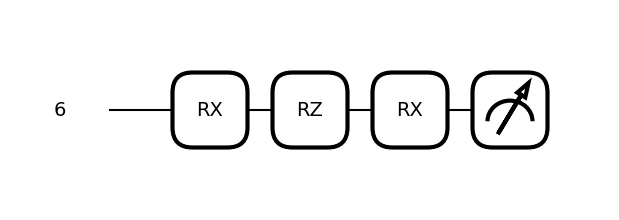

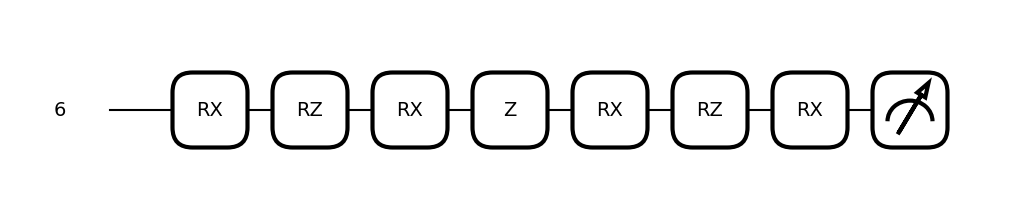

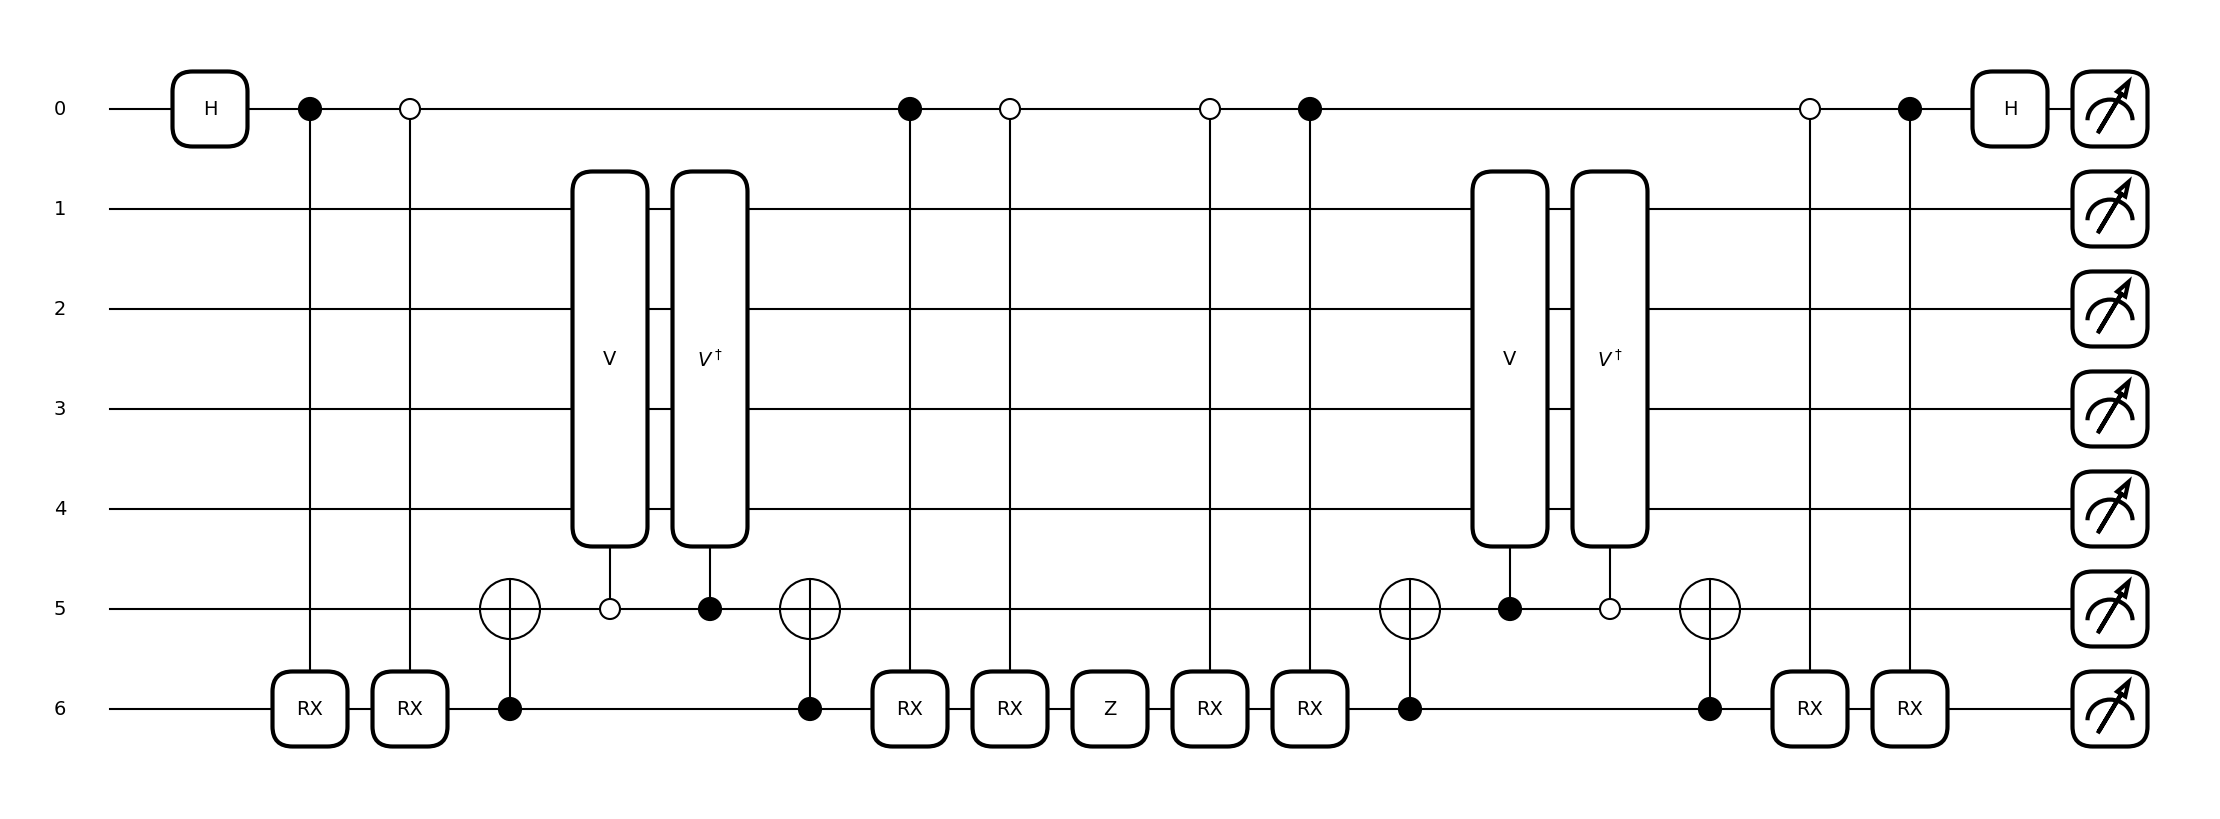

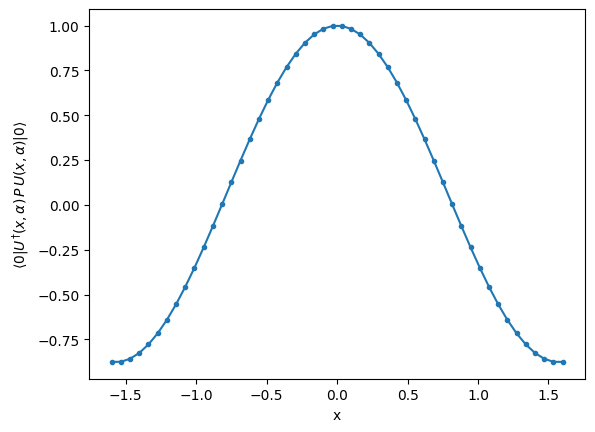

Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Computing train kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/49 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:918: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


...

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Computing train kernel:   0%|          | 0/45 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


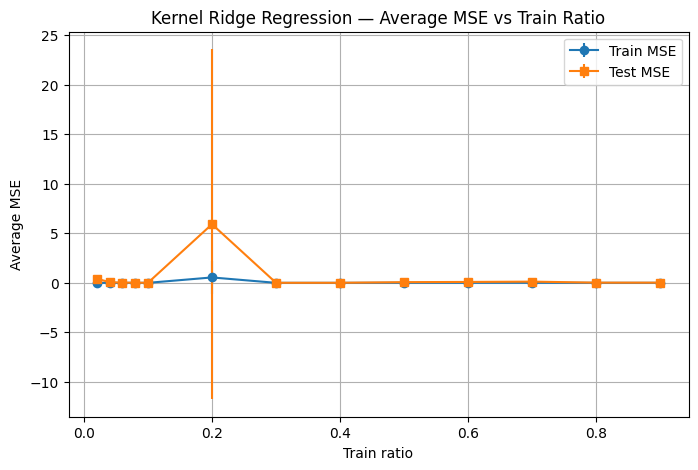

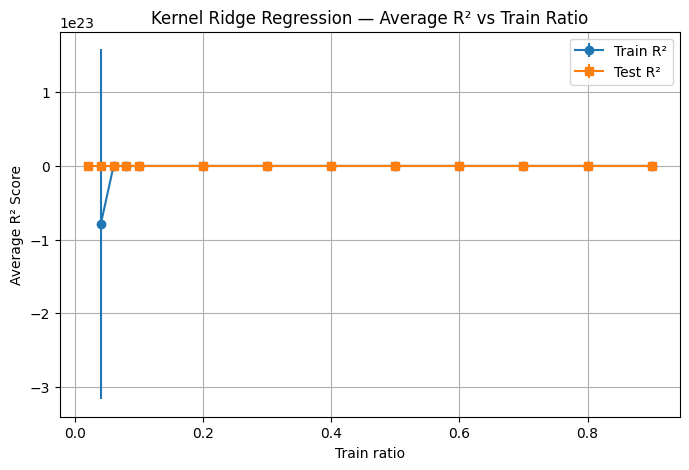

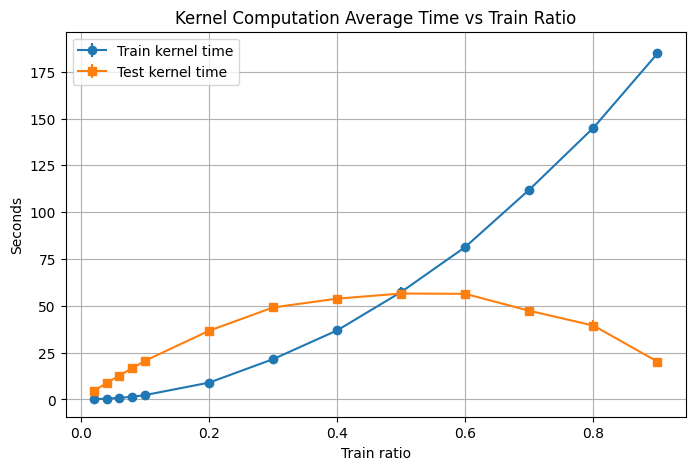


   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)

Train/Test Ratio = 0.98
  Avg Train MSE = 0.000000
  Avg Test  MSE = 0.421540
  Test/Train MSE Ratio = 874013.4148
----------------------------------------------
Train/Test Ratio = 0.96
  Avg Train MSE = 0.000049
  Avg Test  MSE = 0.067397
  Test/Train MSE Ratio = 1371.3532
----------------------------------------------
Train/Test Ratio = 0.94
  Avg Train MSE = 0.000028
  Avg Test  MSE = 0.021187
  Test/Train MSE Ratio = 751.5908
----------------------------------------------
Train/Test Ratio = 0.92
  Avg Train MSE = 0.000074
  Avg Test  MSE = 0.012483
  Test/Train MSE Ratio = 167.6601
----------------------------------------------
Train/Test Ratio = 0.9
  Avg Train MSE = 0.000107
  Avg Test  MSE = 0.007235
  Test/Train MSE Ratio = 67.8956
----------------------------------------------
Train/Test Ratio = 0.8
  Avg Train MSE = 0.545261
  Avg Test  MSE = 5.920752
  Test/Train MSE Ratio = 10.8586
----------------------------------------------

In [2]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-1.6]), np.array([-1.5346938775510206]), np.array([-1.469387755102041]), np.array([-1.4040816326530612]), np.array([-1.3387755102040817]), np.array([-1.2734693877551022]), np.array([-1.2081632653061225]), np.array([-1.1428571428571428]), np.array([-1.0775510204081633]), np.array([-1.0122448979591838]), np.array([-0.9469387755102041]), np.array([-0.8816326530612245]), np.array([-0.8163265306122449]), np.array([-0.7510204081632653]), np.array([-0.6857142857142857]), np.array([-0.6204081632653061]), np.array([-0.5551020408163265]), np.array([-0.48979591836734704]), np.array([-0.42448979591836733]), np.array([-0.3591836734693876]), np.array([-0.29387755102040813]), np.array([-0.22857142857142865]), np.array([-0.16326530612244894]), np.array([-0.09795918367346923]), np.array([-0.03265306122448974]), np.array([0.03265306122448974]), np.array([0.09795918367346945]), np.array([0.16326530612244916]), np.array([0.22857142857142865]), np.array([0.29387755102040813]), np.array([0.35918367346938784]), np.array([0.42448979591836755]), np.array([0.48979591836734704]), np.array([0.5551020408163265]), np.array([0.620408163265306]), np.array([0.6857142857142859]), np.array([0.7510204081632654]), np.array([0.8163265306122449]), np.array([0.8816326530612248]), np.array([0.9469387755102043]), np.array([1.0122448979591838]), np.array([1.0775510204081633]), np.array([1.1428571428571428]), np.array([1.2081632653061227]), np.array([1.2734693877551022]), np.array([1.3387755102040817]), np.array([1.4040816326530616]), np.array([1.4693877551020411]), np.array([1.5346938775510206]), np.array([1.6])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.8, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel", leave = False):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel", leave = False):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
test_ratios = [0.98, 0.96, 0.94, 0.92, 0.90,
               0.80, 0.70, 0.60, 0.50,
               0.40, 0.30, 0.20, 0.10]

n_seeds = 10
seeds = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]

# store shapes:
n_ratios = len(test_ratios)

mse_train_arr = np.zeros((n_seeds, n_ratios))
mse_test_arr  = np.zeros((n_seeds, n_ratios))
r2_train_arr  = np.zeros((n_seeds, n_ratios))
r2_test_arr   = np.zeros((n_seeds, n_ratios))

kernel_train_time_arr = np.zeros((n_seeds, n_ratios))
kernel_test_time_arr  = np.zeros((n_seeds, n_ratios))


# # ---------------------------------------------------------
# # MAIN SWEEP
# # ---------------------------------------------------------
for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave = False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )

        # -------------------------
        # Compute TRAIN kernel (timed)
        # -------------------------
        start = time.time()
        K_train = compute_kernel_matrix_train(X_train, alpha)
        kernel_train_time_arr[s_idx, r_idx] = time.time() - start

        # -------------------------
        # Compute TEST kernel (timed)
        # -------------------------
        start = time.time()
        K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
        kernel_test_time_arr[s_idx, r_idx] = time.time() - start

        # -------------------------
        # Kernel Ridge Regression
        # -------------------------
        krr = KernelRidge(alpha=1e-3, kernel='precomputed')
        krr.fit(K_train, Y_train)

        Y_train_pred = krr.predict(K_train)
        Y_test_pred  = krr.predict(K_test)

        # -------------------------
        # Metrics
        # -------------------------
        mse_train_arr[s_idx, r_idx] = mean_squared_error(Y_train, Y_train_pred)
        mse_test_arr[s_idx, r_idx]  = mean_squared_error(Y_test, Y_test_pred)

        r2_train_arr[s_idx, r_idx]  = r2_score(Y_train, Y_train_pred)
        r2_test_arr[s_idx, r_idx]   = r2_score(Y_test, Y_test_pred)


# ---------------------------------------------------------
# COMPUTE MEANS + STANDARD DEVIATION
# ---------------------------------------------------------

train_ratios = [1 - r for r in test_ratios]

mse_train_mean = mse_train_arr.mean(axis=0)
mse_test_mean  = mse_test_arr.mean(axis=0)
mse_train_std  = mse_train_arr.std(axis=0)
mse_test_std   = mse_test_arr.std(axis=0)

r2_train_mean = r2_train_arr.mean(axis=0)
r2_test_mean  = r2_test_arr.mean(axis=0)
r2_train_std  = r2_train_arr.std(axis=0)
r2_test_std   = r2_test_arr.std(axis=0)

kernel_train_mean = kernel_train_time_arr.mean(axis=0)
kernel_test_mean  = kernel_test_time_arr.mean(axis=0)
kernel_train_std  = kernel_train_time_arr.std(axis=0)
kernel_test_std   = kernel_test_time_arr.std(axis=0)


# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE")
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²")
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²")
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time")
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time")
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# PER-RATIO SUMMARY STATISTICS (AVERAGED OVER SEEDS)
# ---------------------------------------------------------
print("\n==============================================")
print("   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)")
print("==============================================\n")

for r_idx, ratio in enumerate(test_ratios):

    avg_train_mse = mse_train_arr[:, r_idx].mean()
    avg_test_mse  = mse_test_arr[:, r_idx].mean()
    ratio_val = avg_test_mse / avg_train_mse if avg_train_mse > 0 else np.nan

    print(f"Train/Test Ratio = {ratio}")
    print(f"  Avg Train MSE = {avg_train_mse:.6f}")
    print(f"  Avg Test  MSE = {avg_test_mse:.6f}")
    print(f"  Test/Train MSE Ratio = {ratio_val:.4f}")
    print("----------------------------------------------")



## Main Plots with error bars

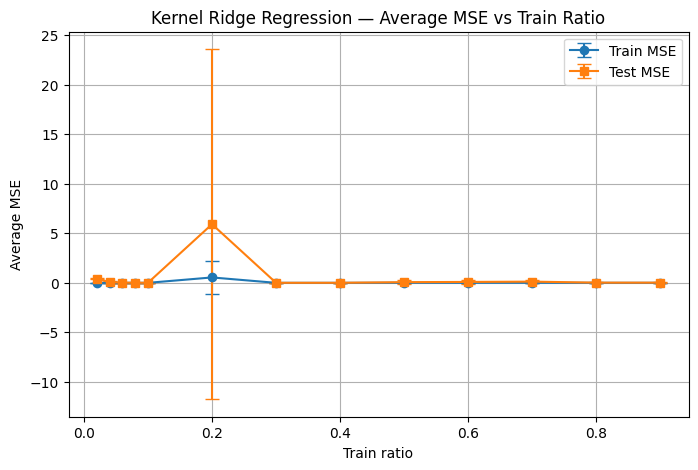

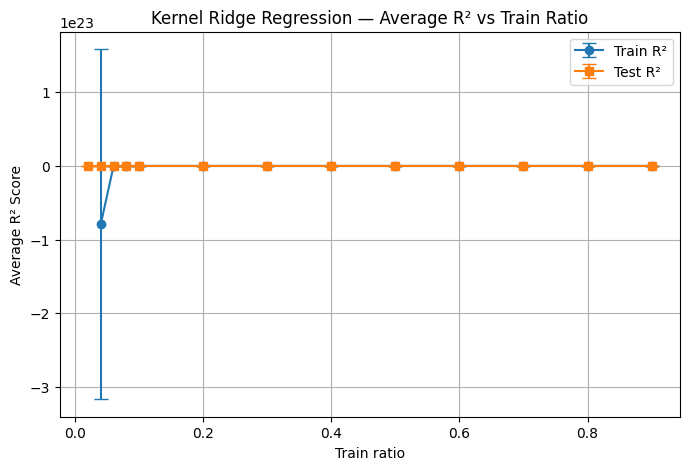

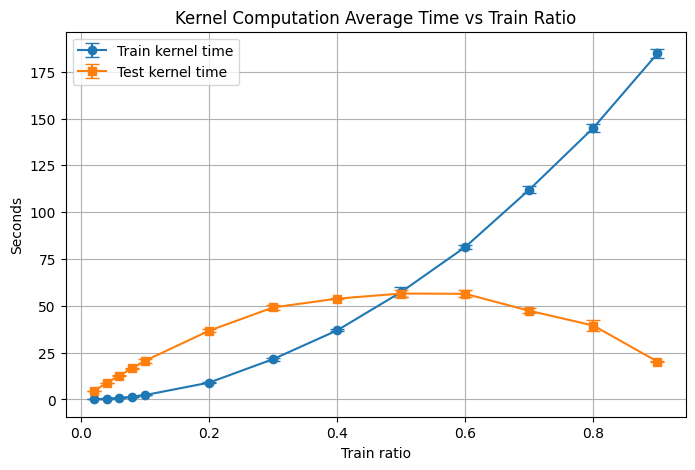

In [3]:

# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE", capsize=5)
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²",capsize=5)
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time",capsize=5)
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## MSE plot without error bars

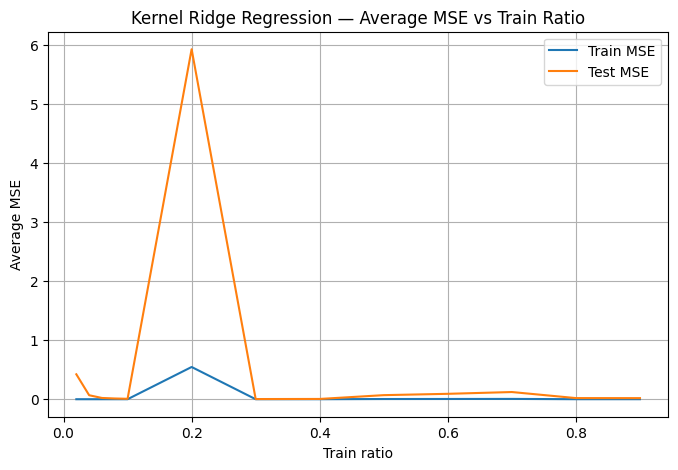

In [4]:
plt.figure(figsize=(8,5))
plt.plot(train_ratios, mse_train_mean,   label="Train MSE")
plt.plot(train_ratios, mse_test_mean,    label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

## MSE plots with y limited to 0.1

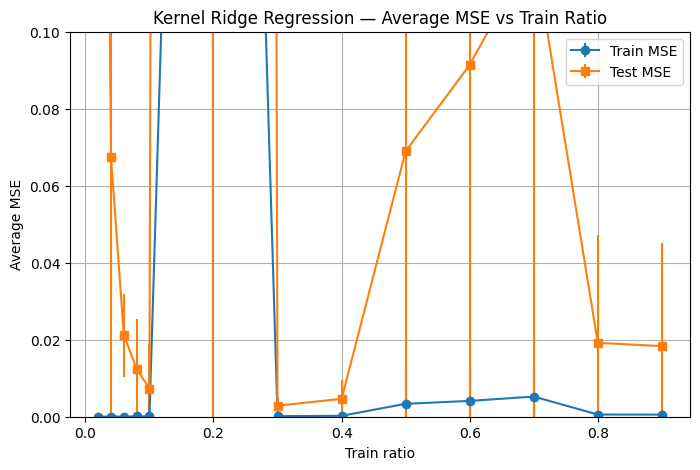

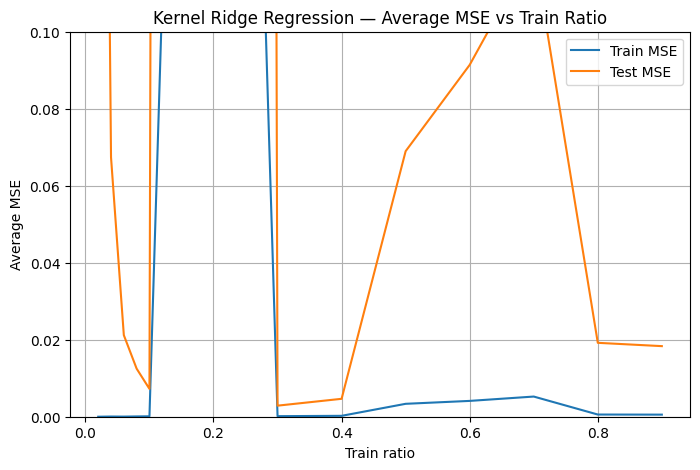

In [5]:

# ---------------------------------------------------------
# PLOTS WITH ERROR BARS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE")
plt.errorbar(train_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.ylim(0,0.1)
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_ratios, mse_train_mean,   label="Train MSE")
plt.plot(train_ratios, mse_test_mean,    label="Test MSE")
plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.ylim(0,0.1)
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## MSE Data per train test ratio

In [6]:

# ---------------------------------------------------------
# PER-RATIO SUMMARY STATISTICS (AVERAGED OVER SEEDS)
# ---------------------------------------------------------
print("\n==============================================")
print("   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)")
print("==============================================\n")

ratio_vals = []
for r_idx, ratio in enumerate(train_ratios):

    avg_train_mse = mse_train_arr[:, r_idx].mean()
    avg_test_mse  = mse_test_arr[:, r_idx].mean()
    ratio_val = avg_test_mse / avg_train_mse if avg_train_mse > 0 else np.nan
    ratio_vals.append(ratio_val)
    print(f"Train Ratio = {ratio}")
    print(f"  Avg Train MSE = {avg_train_mse:.6e}")
    print(f"  Avg Test  MSE = {avg_test_mse:.6e}")
    print(f"  Test/Train MSE Ratio = {ratio_val:.4e}")
    print("----------------------------------------------")




   PERFORMANCE SUMMARY (AVERAGED OVER SEEDS)

Train Ratio = 0.020000000000000018
  Avg Train MSE = 4.823034e-07
  Avg Test  MSE = 4.215396e-01
  Test/Train MSE Ratio = 8.7401e+05
----------------------------------------------
Train Ratio = 0.040000000000000036
  Avg Train MSE = 4.914603e-05
  Avg Test  MSE = 6.739657e-02
  Test/Train MSE Ratio = 1.3714e+03
----------------------------------------------
Train Ratio = 0.06000000000000005
  Avg Train MSE = 2.818994e-05
  Avg Test  MSE = 2.118730e-02
  Test/Train MSE Ratio = 7.5159e+02
----------------------------------------------
Train Ratio = 0.07999999999999996
  Avg Train MSE = 7.445152e-05
  Avg Test  MSE = 1.248255e-02
  Test/Train MSE Ratio = 1.6766e+02
----------------------------------------------
Train Ratio = 0.09999999999999998
  Avg Train MSE = 1.065621e-04
  Avg Test  MSE = 7.235099e-03
  Test/Train MSE Ratio = 6.7896e+01
----------------------------------------------
Train Ratio = 0.19999999999999996
  Avg Train MSE = 5.45

## Ratio of test to train error plot

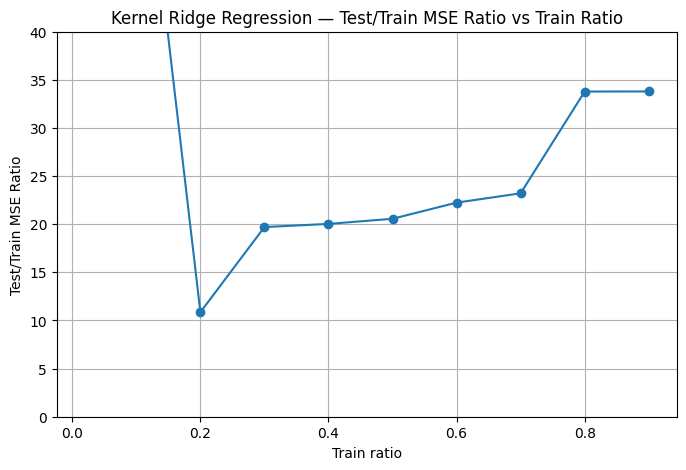

In [7]:
plt.figure(figsize=(8,5))
# plot ratio values vs train ratio
plt.plot(train_ratios, ratio_vals, "o-")
plt.xlabel("Train ratio")
plt.ylabel("Test/Train MSE Ratio")
plt.title("Kernel Ridge Regression — Test/Train MSE Ratio vs Train Ratio")
plt.ylim(0,40)
plt.grid(True)
plt.show()

## Plots for R2 and time

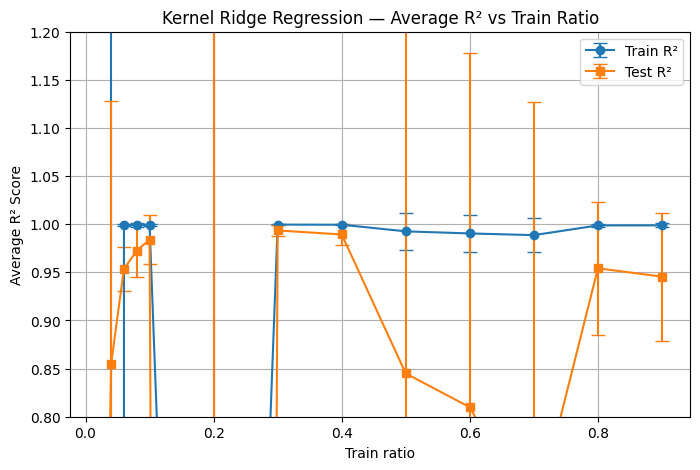

In [8]:
plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R²",capsize=5)
plt.errorbar(train_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R²",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.ylim(0.8,1.2)
plt.legend()
plt.grid(True)
plt.show()


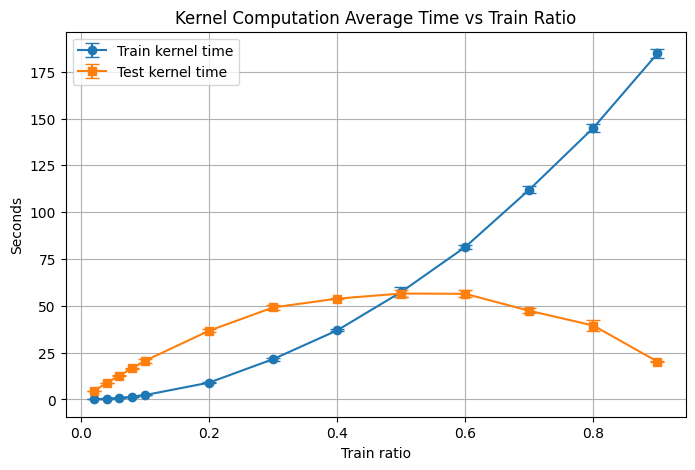

In [9]:

plt.figure(figsize=(8,5))
plt.errorbar(train_ratios, kernel_train_mean, yerr=kernel_train_std, fmt="o-", label="Train kernel time",capsize=5)
plt.errorbar(train_ratios, kernel_test_mean,  yerr=kernel_test_std,  fmt="s-", label="Test kernel time",capsize=5)
plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()

## Printing data if needed later

In [10]:
print(test_ratios)
print(train_ratios)

[0.98, 0.96, 0.94, 0.92, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
[0.020000000000000018, 0.040000000000000036, 0.06000000000000005, 0.07999999999999996, 0.09999999999999998, 0.19999999999999996, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [11]:

print(mse_train_arr)
print(mse_test_arr)


[[1.39825231e-08 9.62906965e-06 2.70894511e-05 2.66460674e-04
  7.32902568e-05 6.28916996e-05 2.14027502e-05 3.25522387e-04
  2.62200097e-05 9.64383910e-03 4.91225112e-04 3.08289758e-05
  3.55256580e-05]
 [7.35276552e-07 1.25238977e-04 1.60370356e-05 1.40022826e-05
  1.76003199e-04 3.20852601e-04 3.44032351e-05 1.02246186e-04
  2.70943939e-04 8.87787586e-05 5.28702136e-05 1.29917683e-04
  2.47643149e-04]
 [6.04550892e-07 1.06187438e-04 2.45104136e-05 1.24875762e-04
  2.05879203e-04 5.39115940e-03 2.03735890e-04 5.14710820e-05
  1.12213331e-05 1.02047028e-04 1.49793027e-02 6.46139189e-04
  8.04382058e-06]
 [7.64334301e-07 2.82484420e-06 2.18655846e-06 7.02091578e-06
  8.20805598e-06 1.28946381e-04 2.95932502e-04 5.68225855e-05
  7.96280410e-04 1.04009737e-04 9.94153079e-03 2.05003372e-04
  2.34483189e-04]
 [5.88656993e-07 1.73520497e-04 7.16202924e-05 7.96876947e-05
  2.76300742e-05 1.83597340e-04 6.19865589e-05 7.36517488e-04
  4.19122111e-05 2.45442164e-03 6.68568187e-04 2.20828616e-0

In [12]:

print(r2_train_arr)
print(r2_test_arr)


[[            nan  9.99963122e-01  9.99848470e-01  9.99066351e-01
   9.99756470e-01  9.99851725e-01  9.99951893e-01  9.99268969e-01
   9.99945070e-01  9.78771235e-01  9.98929706e-01  9.99929527e-01
   9.99924619e-01]
 [            nan  9.21791991e-01  9.99978157e-01  9.99977455e-01
   9.99749525e-01  9.99465107e-01  9.99942734e-01  9.99791602e-01
   9.99440068e-01  9.99816288e-01  9.99886337e-01  9.99717524e-01
   9.99466268e-01]
 [            nan  9.33689110e-01  9.99962861e-01  9.99778857e-01
   9.99544372e-01  9.87675001e-01  9.99463223e-01  9.99858612e-01
   9.99974618e-01  9.99759313e-01  9.68593413e-01  9.98650398e-01
   9.99982772e-01]
 [            nan  9.99991029e-01  9.99989598e-01  9.99955498e-01
   9.99951864e-01  9.99699198e-01  9.99314009e-01  9.99884225e-01
   9.98449090e-01  9.99781144e-01  9.79536928e-01  9.99569957e-01
   9.99507032e-01]
 [            nan  9.07220288e-01  9.99874497e-01  9.99816652e-01
   9.99944547e-01  9.99622922e-01  9.99850112e-01  9.98513532e-01


In [13]:

print(kernel_train_time_arr)
print(kernel_test_time_arr)

[[9.67948437e-02 3.97760153e-01 7.86992311e-01 1.44613028e+00
  2.19361353e+00 9.02081728e+00 2.13425357e+01 3.61207242e+01
  5.61240392e+01 8.22359145e+01 1.09801138e+02 1.47062874e+02
  1.83033109e+02]
 [1.00680590e-01 3.65713596e-01 8.02991152e-01 1.46723962e+00
  2.32534933e+00 9.02330780e+00 2.21167917e+01 3.59024177e+01
  5.62121270e+01 8.28432498e+01 1.10395571e+02 1.43791896e+02
  1.84610251e+02]
 [1.05584621e-01 3.98003340e-01 8.20625305e-01 1.46665287e+00
  2.28907013e+00 9.07915139e+00 2.22291918e+01 3.69984558e+01
  6.24826791e+01 8.27364738e+01 1.12408387e+02 1.46020895e+02
  1.84842863e+02]
 [1.09021902e-01 3.75615597e-01 8.04089785e-01 1.48620176e+00
  2.31781769e+00 9.08484983e+00 2.21845925e+01 3.67876396e+01
  5.63372192e+01 8.06327724e+01 1.11570952e+02 1.44849160e+02
  1.83919944e+02]
 [1.02613211e-01 3.62276316e-01 8.12648296e-01 1.43961334e+00
  2.30198622e+00 8.91515946e+00 2.11997716e+01 3.73058715e+01
  5.56321118e+01 8.09713707e+01 1.16547403e+02 1.43963999e+0

## Nicer looking error plots

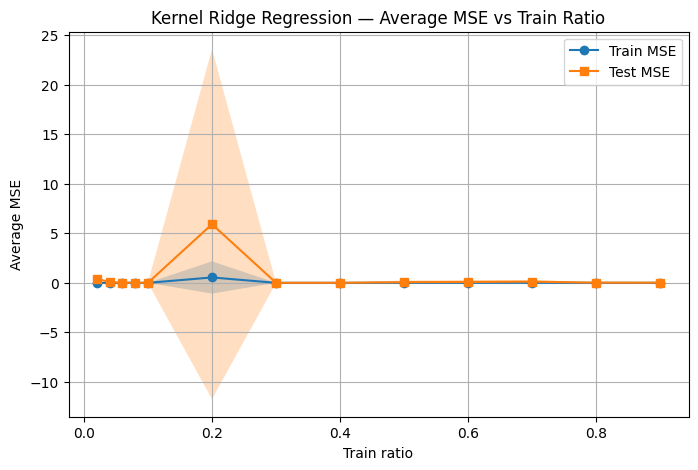

In [14]:
plt.figure(figsize=(8,5))

# Train MSE
plt.plot(train_ratios, mse_train_mean, "o-", label="Train MSE")
plt.fill_between(train_ratios,
                 mse_train_mean - mse_train_std,
                 mse_train_mean + mse_train_std,
                 alpha=0.25)

# Test MSE
plt.plot(train_ratios, mse_test_mean, "s-", label="Test MSE")
plt.fill_between(train_ratios,
                 mse_test_mean - mse_test_std,
                 mse_test_mean + mse_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


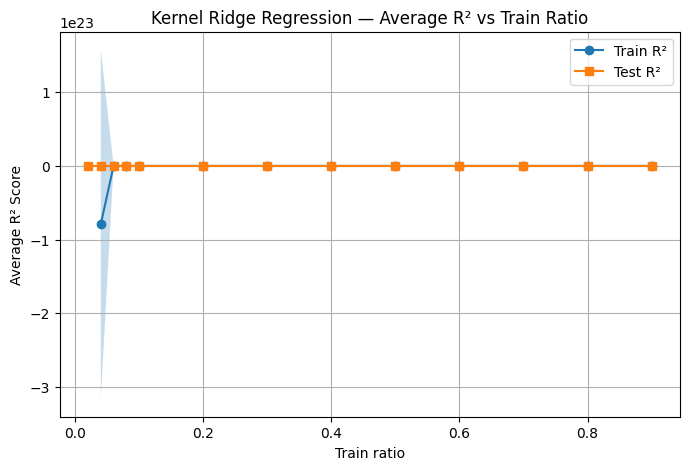

In [15]:
plt.figure(figsize=(8,5))

# Train R2
plt.plot(train_ratios, r2_train_mean, "o-", label="Train R²")
plt.fill_between(train_ratios,
                 r2_train_mean - r2_train_std,
                 r2_train_mean + r2_train_std,
                 alpha=0.25)

# Test R2
plt.plot(train_ratios, r2_test_mean, "s-", label="Test R²")
plt.fill_between(train_ratios,
                 r2_test_mean - r2_test_std,
                 r2_test_mean + r2_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Average R² Score")
plt.title("Kernel Ridge Regression — Average R² vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


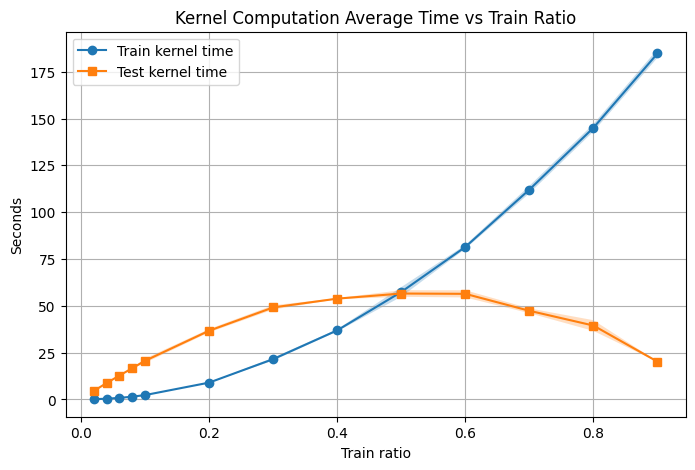

In [16]:
plt.figure(figsize=(8,5))

# Train kernel time
plt.plot(train_ratios, kernel_train_mean, "o-", label="Train kernel time")
plt.fill_between(train_ratios,
                 kernel_train_mean - kernel_train_std,
                 kernel_train_mean + kernel_train_std,
                 alpha=0.25)

# Test kernel time
plt.plot(train_ratios, kernel_test_mean, "s-", label="Test kernel time")
plt.fill_between(train_ratios,
                 kernel_test_mean - kernel_test_std,
                 kernel_test_mean + kernel_test_std,
                 alpha=0.25)

plt.xlabel("Train ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Average Time vs Train Ratio")
plt.legend()
plt.grid(True)
plt.show()


## Printing more data if needed later 

In [17]:
for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave = False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )
        print(f"Seed = {seed}")
        print(f"Ratio = {ratio}")
        print(f"Train Data = {X_train}")
        print(f"Test Data = {X_test}")
        print(f"Train Labels = {Y_train}")
        print(f"Test Labels = {Y_test}")
        print("----------------------------------------------")

Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 42
Ratio = 0.98
Train Data = [array([0.88163265])]
Test Data = [array([-0.75102041]), array([0.94693878]), array([0.35918367]), array([1.33877551]), array([-0.48979592]), array([1.53469388]), array([0.09795918]), array([0.03265306]), array([0.48979592]), array([-0.35918367]), array([-0.81632653]), array([-1.33877551]), array([0.81632653]), array([-1.07755102]), array([-1.40408163]), array([-1.20816327]), array([1.07755102]), array([1.40408163]), array([1.46938776]), array([-0.62040816]), array([-1.0122449]), array([-0.55510204]), array([-0.03265306]), array([0.62040816]), array([0.4244898]), array([-1.6]), array([1.27346939]), array([0.16326531]), array([0.55510204]), array([-1.27346939]), array([0.29387755]), array([-0.88163265]), array([0.75102041]), array([-1.53469388]), array([-0.22857143]), array([-1.46938776]), array([1.20816327]), array([0.68571429]), array([-0.09795918]), array([1.0122449]), array([-0.94693878]), array([-0.16326531]), array([-0.4244898]), array([1.6]), a

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 7
Ratio = 0.98
Train Data = [array([1.46938776])]
Test Data = [array([-0.75102041]), array([-0.62040816]), array([-0.16326531]), array([1.14285714]), array([0.35918367]), array([0.16326531]), array([-1.53469388]), array([-0.29387755]), array([-0.94693878]), array([0.75102041]), array([0.48979592]), array([1.40408163]), array([0.62040816]), array([-0.4244898]), array([-0.48979592]), array([0.68571429]), array([0.29387755]), array([1.07755102]), array([-1.0122449]), array([-1.46938776]), array([0.55510204]), array([-0.55510204]), array([-0.22857143]), array([0.4244898]), array([0.88163265]), array([-0.03265306]), array([-1.27346939]), array([-0.81632653]), array([1.33877551]), array([-1.20816327]), array([0.81632653]), array([1.0122449]), array([-0.88163265]), array([-1.6]), array([-1.14285714]), array([1.53469388]), array([1.20816327]), array([0.09795918]), array([1.6]), array([-1.07755102]), array([1.27346939]), array([-0.68571429]), array([0.22857143]), array([0.94693878]), arr

...

Seed = 88
Ratio = 0.98
Train Data = [array([-0.03265306])]
Test Data = [array([0.88163265]), array([-1.46938776]), array([1.6]), array([-0.48979592]), array([0.75102041]), array([-0.35918367]), array([0.4244898]), array([1.33877551]), array([1.46938776]), array([0.16326531]), array([-0.22857143]), array([1.53469388]), array([-1.0122449]), array([0.22857143]), array([-0.4244898]), array([1.07755102]), array([1.40408163]), array([-1.6]), array([0.68571429]), array([1.0122449]), array([0.94693878]), array([-0.09795918]), array([-0.81632653]), array([-0.68571429]), array([-1.07755102]), array([-0.55510204]), array([-1.53469388]), array([0.35918367]), array([-1.40408163]), array([-0.75102041]), array([0.29387755]), array([-0.16326531]), array([-0.94693878]), array([-1.20816327]), array([1.27346939]), array([0.03265306]), array([0.09795918]), array([-1.14285714]), array([-1.33877551]), array([-0.88163265]), array([1.20816327]), array([0.62040816]), array([-1.27346939]), array([0.55510204]), 

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 314
Ratio = 0.98
Train Data = [array([-1.07755102])]
Test Data = [array([0.55510204]), array([-0.81632653]), array([-0.48979592]), array([-0.94693878]), array([0.09795918]), array([-1.53469388]), array([1.27346939]), array([-0.35918367]), array([-0.88163265]), array([-0.09795918]), array([-1.20816327]), array([-1.27346939]), array([-0.4244898]), array([0.03265306]), array([0.22857143]), array([-0.29387755]), array([-0.22857143]), array([-1.6]), array([0.29387755]), array([0.4244898]), array([-1.40408163]), array([0.75102041]), array([-1.46938776]), array([0.35918367]), array([0.81632653]), array([1.46938776]), array([-0.62040816]), array([0.94693878]), array([0.88163265]), array([1.6]), array([-0.75102041]), array([1.53469388]), array([0.16326531]), array([0.48979592]), array([-1.33877551]), array([-0.03265306]), array([1.0122449]), array([1.07755102]), array([0.68571429]), array([-0.55510204]), array([1.20816327]), array([1.40408163]), array([0.62040816]), array([-1.14285714]),

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Seed = 256
Ratio = 0.98
Train Data = [array([0.48979592])]
Test Data = [array([-0.4244898]), array([0.4244898]), array([0.09795918]), array([1.33877551]), array([-0.48979592]), array([-1.27346939]), array([-0.35918367]), array([0.29387755]), array([-1.07755102]), array([-0.88163265]), array([1.27346939]), array([-0.94693878]), array([1.53469388]), array([0.22857143]), array([1.07755102]), array([0.68571429]), array([-0.22857143]), array([0.16326531]), array([0.35918367]), array([-0.75102041]), array([-0.55510204]), array([0.55510204]), array([0.81632653]), array([-0.16326531]), array([-1.33877551]), array([-0.81632653]), array([-1.40408163]), array([1.46938776]), array([-0.62040816]), array([-0.29387755]), array([1.14285714]), array([1.40408163]), array([-1.6]), array([1.20816327]), array([-1.0122449]), array([1.6]), array([-0.68571429]), array([0.62040816]), array([1.0122449]), array([-1.20816327]), array([0.75102041]), array([-1.14285714]), array([-0.03265306]), array([-1.46938776]),

## Saving plot of train and test data to check if any obvious pattern is visible

In [18]:
import os
os.makedirs("data_image_for_Rz_dimx1_non_periodic", exist_ok=True)

for s_idx, seed in enumerate(tqdm(seeds, desc="Sweeping across seeds")):

    for r_idx, ratio in enumerate(tqdm(test_ratios, desc="Sweeping test ratios", leave=False)):

        # -------------------------
        # Train/test split
        # -------------------------
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=ratio, shuffle=True, random_state=seed
        )

        # -------------------------
        # PLOT TRAIN / TEST POINTS (saved instead of shown)
        # -------------------------
        plt.figure(figsize=(8,4))

        plt.scatter(X_train, Y_train, label="Train points", color="blue", alpha=0.7)
        plt.scatter(X_test,  Y_test,  label="Test points",  color="red", alpha=0.7)

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Train/Test Split (seed={seed}, test_ratio={ratio})")
        plt.legend()
        plt.grid(True)

        # ---- Save figure ----
        filename = f"data_image_for_Rz_dimx1_non_periodic/seed_{seed}_ratio_{ratio}.png"
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        plt.close()   # prevent display & memory buildup


Sweeping across seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

...

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

Sweeping test ratios:   0%|          | 0/13 [00:00<?, ?it/s]

# Varying Train Test Split for single period with k fold cross validation

Varied the train test split with the following % used for test and rest for train: \
0.98, 0.96, 0.94, 0.92, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10 \
$x_0$ taken uniformly from $-\pi/2$ to $\pi/2$

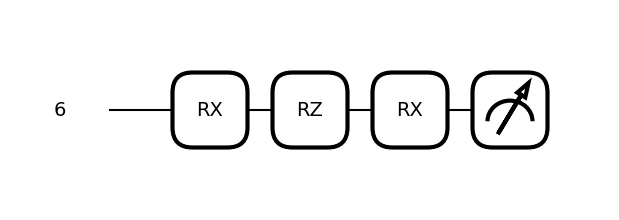

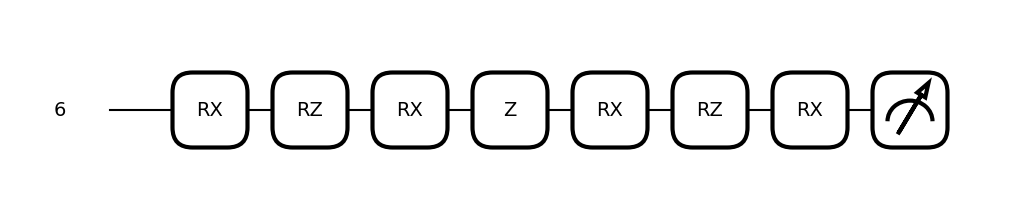

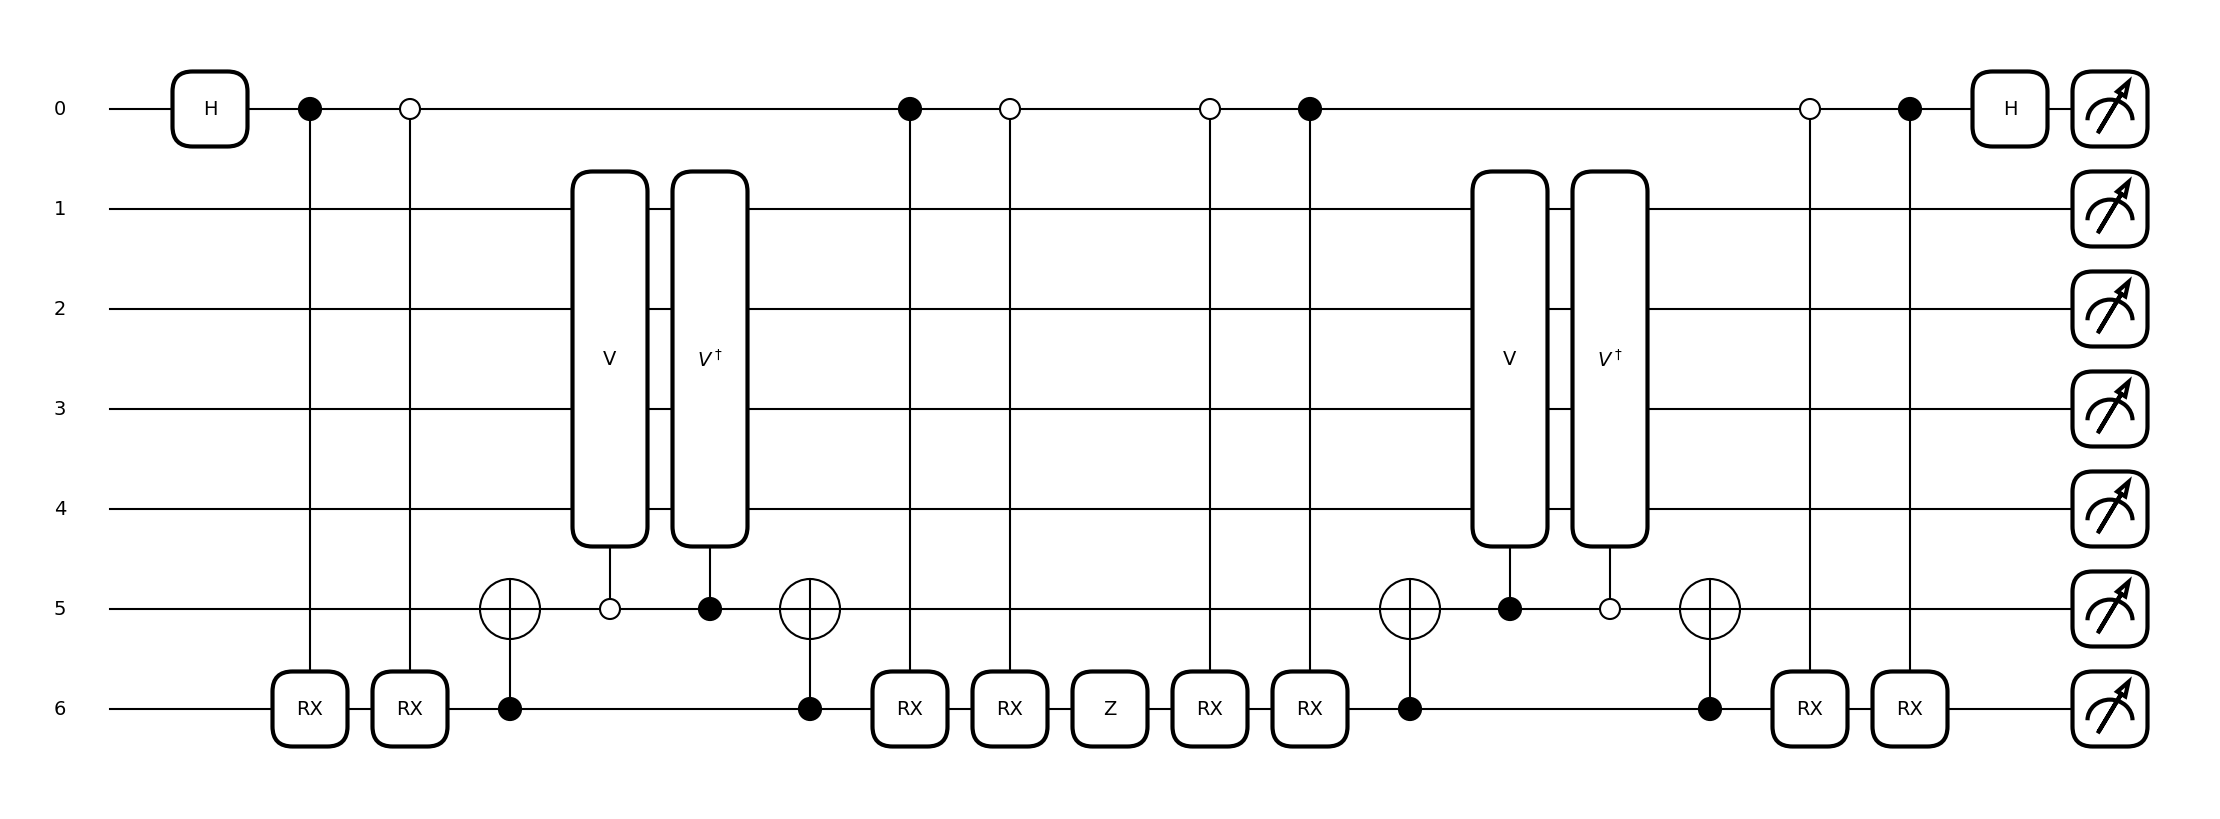

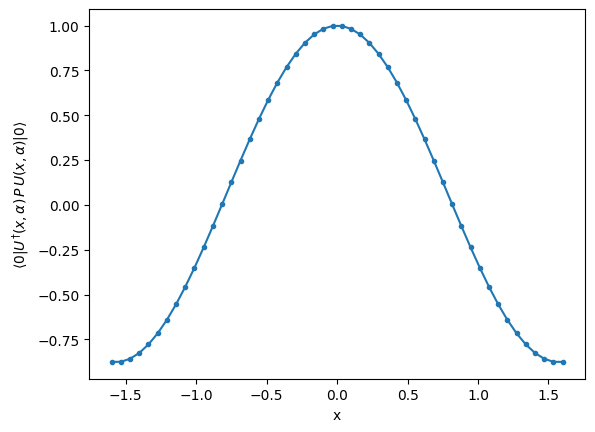

CV over test ratios:   0%|          | 0/6 [00:00<?, ?it/s]


=== Test ratio = 0.6 ===
Using k = 2 (from test_ratio = 0.6)


Computing train kernel:   0%|          | 0/25 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/25 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


...

Computing test kernel:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Computing train kernel:   0%|          | 0/45 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\rjuya\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


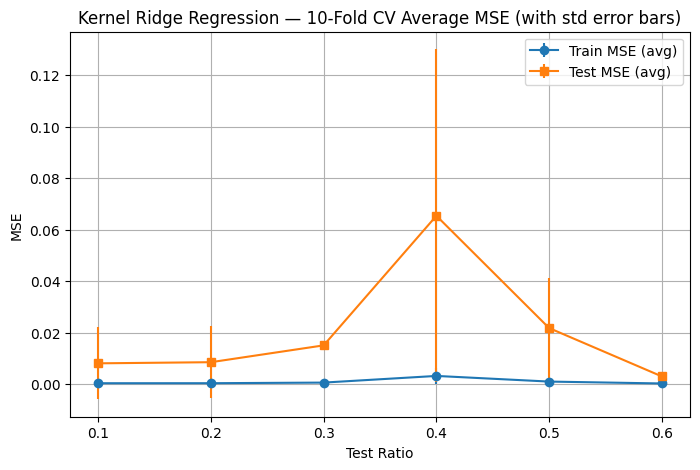

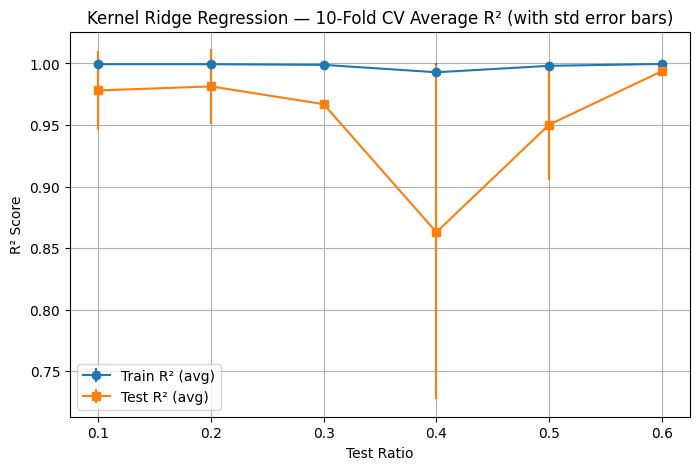

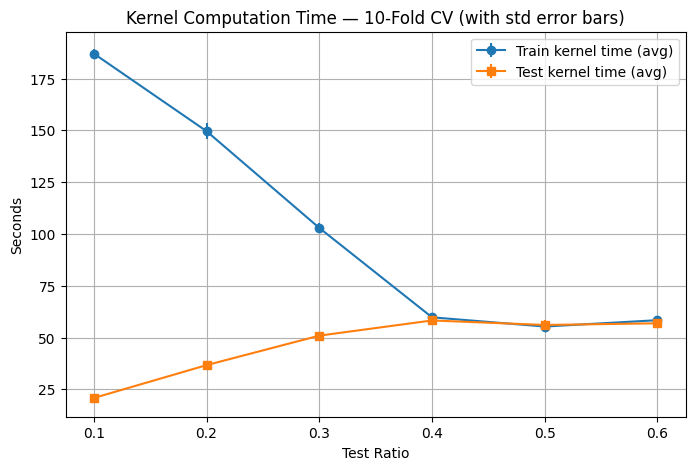

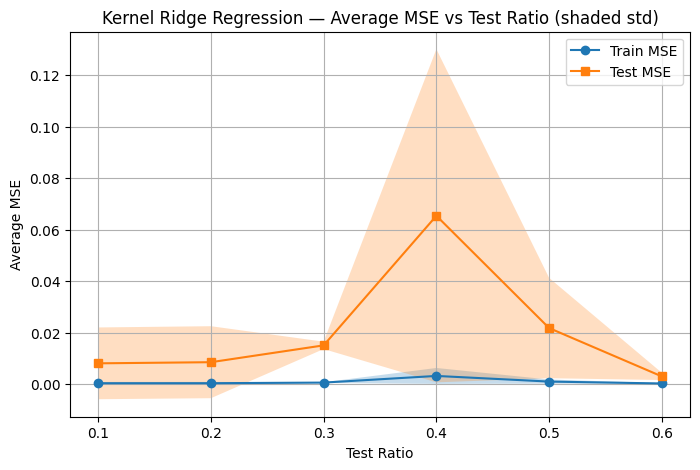

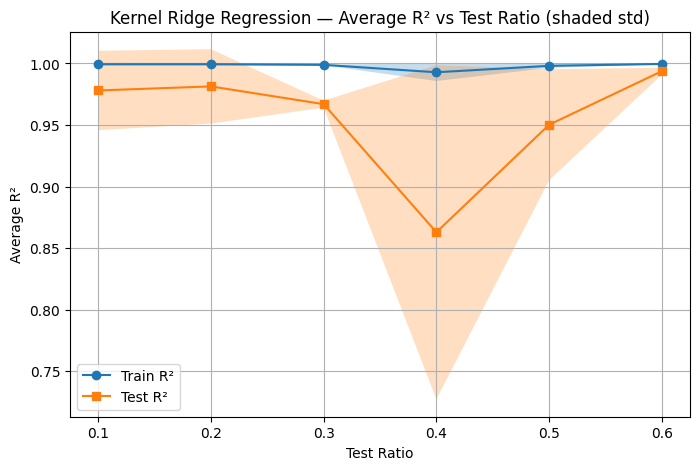

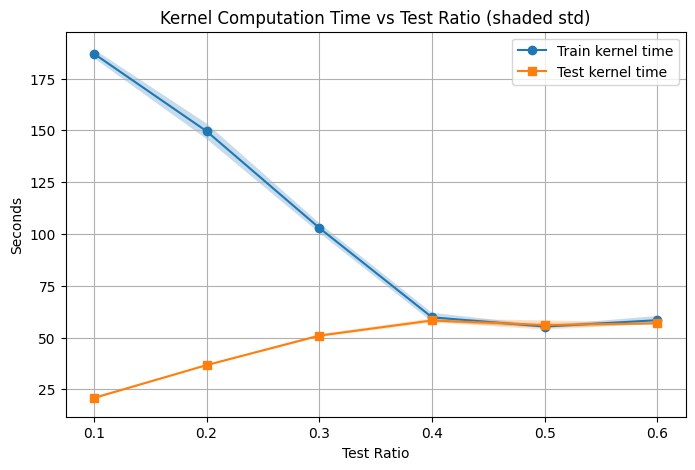

In [2]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-1.6]), np.array([-1.5346938775510206]), np.array([-1.469387755102041]), np.array([-1.4040816326530612]), np.array([-1.3387755102040817]), np.array([-1.2734693877551022]), np.array([-1.2081632653061225]), np.array([-1.1428571428571428]), np.array([-1.0775510204081633]), np.array([-1.0122448979591838]), np.array([-0.9469387755102041]), np.array([-0.8816326530612245]), np.array([-0.8163265306122449]), np.array([-0.7510204081632653]), np.array([-0.6857142857142857]), np.array([-0.6204081632653061]), np.array([-0.5551020408163265]), np.array([-0.48979591836734704]), np.array([-0.42448979591836733]), np.array([-0.3591836734693876]), np.array([-0.29387755102040813]), np.array([-0.22857142857142865]), np.array([-0.16326530612244894]), np.array([-0.09795918367346923]), np.array([-0.03265306122448974]), np.array([0.03265306122448974]), np.array([0.09795918367346945]), np.array([0.16326530612244916]), np.array([0.22857142857142865]), np.array([0.29387755102040813]), np.array([0.35918367346938784]), np.array([0.42448979591836755]), np.array([0.48979591836734704]), np.array([0.5551020408163265]), np.array([0.620408163265306]), np.array([0.6857142857142859]), np.array([0.7510204081632654]), np.array([0.8163265306122449]), np.array([0.8816326530612248]), np.array([0.9469387755102043]), np.array([1.0122448979591838]), np.array([1.0775510204081633]), np.array([1.1428571428571428]), np.array([1.2081632653061227]), np.array([1.2734693877551022]), np.array([1.3387755102040817]), np.array([1.4040816326530616]), np.array([1.4693877551020411]), np.array([1.5346938775510206]), np.array([1.6])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.8, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# ----------------------------------------------------
# 10-fold cross-validation function
# ----------------------------------------------------
def cross_validate_kernel_krr_with_time(X, Y, α, n_splits=10):
    """
    Performs n_splits CV on given X,Y and returns means & stds for MSE, R2, and kernel compute times.
    X and Y must be indexable (e.g. numpy arrays or lists).
    """
    X = np.array(X)
    Y = np.array(Y)

    mse_train_folds = []
    mse_test_folds  = []
    r2_train_folds  = []
    r2_test_folds   = []

    kernel_time_train_folds = []
    kernel_time_test_folds  = []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        # indexing
        X_train = X[train_idx]
        X_test  = X[test_idx]
        Y_train = Y[train_idx]
        Y_test  = Y[test_idx]

        # ---------- compute train kernel with timing ----------
        t0 = time.time()
        K_train = compute_kernel_matrix_train(X_train, α)
        t1 = time.time()
        kernel_time_train_folds.append(t1 - t0)

        # ---------- compute test kernel with timing ----------
        t0 = time.time()
        K_test = compute_kernel_matrix_test(X_test, X_train, α)
        t1 = time.time()
        kernel_time_test_folds.append(t1 - t0)

        # ---------- train KRR ----------
        krr = KernelRidge(alpha=1e-3, kernel='precomputed')
        krr.fit(K_train, Y_train)

        Y_train_pred = krr.predict(K_train)
        Y_test_pred  = krr.predict(K_test)

        # ---------- metrics ----------
        mse_train_folds.append(mean_squared_error(Y_train, Y_train_pred))
        mse_test_folds.append(mean_squared_error(Y_test, Y_test_pred))
        r2_train_folds.append(r2_score(Y_train, Y_train_pred))
        r2_test_folds.append(r2_score(Y_test, Y_test_pred))

    # aggregate into means and stds
    def stat(arr): return (np.mean(arr), np.std(arr))

    return {
        "mse_train_mean": stat(mse_train_folds)[0],
        "mse_train_std":  stat(mse_train_folds)[1],
        "mse_test_mean":  stat(mse_test_folds)[0],
        "mse_test_std":   stat(mse_test_folds)[1],
        "r2_train_mean":  stat(r2_train_folds)[0],
        "r2_train_std":   stat(r2_train_folds)[1],
        "r2_test_mean":   stat(r2_test_folds)[0],
        "r2_test_std":    stat(r2_test_folds)[1],
        "time_train_mean": stat(kernel_time_train_folds)[0],
        "time_train_std":  stat(kernel_time_train_folds)[1],
        "time_test_mean":  stat(kernel_time_test_folds)[0],
        "time_test_std":   stat(kernel_time_test_folds)[1],
    }


# ---------- Sweep test ratios; convert test_ratio -> k-fold ----------

test_ratios = [0.60, 0.50, 0.40, 0.30, 0.20, 0.10]

mse_train_mean = []
mse_train_std  = []
mse_test_mean  = []
mse_test_std   = []

r2_train_mean  = []
r2_train_std   = []
r2_test_mean   = []
r2_test_std    = []

time_train_mean = []
time_train_std  = []
time_test_mean  = []
time_test_std   = []

for ratio in tqdm(test_ratios, desc="CV over test ratios"):
    print(f"\n=== Test ratio = {ratio} ===")

    # ---- convert test_ratio → k folds ----
    k = round(1 / ratio)
    if k<2:
        print("K is less than 2")
        continue
    k = max(k, 2)     # ensure at least 2-fold
    print(f"Using k = {k} (from test_ratio = {ratio})")

    # ---- run cross-validation with computed k ----
    cv_res = cross_validate_kernel_krr_with_time(X, Y, alpha, n_splits=k)

    mse_train_mean.append(cv_res["mse_train_mean"])
    mse_train_std.append(cv_res["mse_train_std"])
    mse_test_mean.append(cv_res["mse_test_mean"])
    mse_test_std.append(cv_res["mse_test_std"])

    r2_train_mean.append(cv_res["r2_train_mean"])
    r2_train_std.append(cv_res["r2_train_std"])
    r2_test_mean.append(cv_res["r2_test_mean"])
    r2_test_std.append(cv_res["r2_test_std"])

    time_train_mean.append(cv_res["time_train_mean"])
    time_train_std.append(cv_res["time_train_std"])
    time_test_mean.append(cv_res["time_test_mean"])
    time_test_std.append(cv_res["time_test_std"])



# ---------- PLOT: Errorbar (MSE, R2, Time) ----------
plt.figure(figsize=(8,5))
plt.errorbar(test_ratios, mse_train_mean, yerr=mse_train_std, fmt="o-", label="Train MSE (avg)")
plt.errorbar(test_ratios, mse_test_mean,  yerr=mse_test_std,  fmt="s-", label="Test MSE (avg)")
plt.xlabel("Test Ratio")
plt.ylabel("MSE")
plt.title("Kernel Ridge Regression — 10-Fold CV Average MSE (with std error bars)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(test_ratios, r2_train_mean, yerr=r2_train_std, fmt="o-", label="Train R² (avg)")
plt.errorbar(test_ratios, r2_test_mean,  yerr=r2_test_std,  fmt="s-", label="Test R² (avg)")
plt.xlabel("Test Ratio")
plt.ylabel("R² Score")
plt.title("Kernel Ridge Regression — 10-Fold CV Average R² (with std error bars)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.errorbar(test_ratios, time_train_mean, yerr=time_train_std, fmt="o-", label="Train kernel time (avg)")
plt.errorbar(test_ratios, time_test_mean,  yerr=time_test_std,  fmt="s-", label="Test kernel time (avg)")
plt.xlabel("Test Ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Time — 10-Fold CV (with std error bars)")
plt.legend()
plt.grid(True)
plt.show()


# ---------- PLOT: Shaded std-band (MSE, R2, Time) ----------
plt.figure(figsize=(8,5))
plt.plot(test_ratios, mse_train_mean, "o-", label="Train MSE")
plt.fill_between(test_ratios,
                 np.array(mse_train_mean) - np.array(mse_train_std),
                 np.array(mse_train_mean) + np.array(mse_train_std),
                 alpha=0.25)
plt.plot(test_ratios, mse_test_mean, "s-", label="Test MSE")
plt.fill_between(test_ratios,
                 np.array(mse_test_mean) - np.array(mse_test_std),
                 np.array(mse_test_mean) + np.array(mse_test_std),
                 alpha=0.25)
plt.xlabel("Test Ratio")
plt.ylabel("Average MSE")
plt.title("Kernel Ridge Regression — Average MSE vs Test Ratio (shaded std)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(test_ratios, r2_train_mean, "o-", label="Train R²")
plt.fill_between(test_ratios,
                 np.array(r2_train_mean) - np.array(r2_train_std),
                 np.array(r2_train_mean) + np.array(r2_train_std),
                 alpha=0.25)
plt.plot(test_ratios, r2_test_mean, "s-", label="Test R²")
plt.fill_between(test_ratios,
                 np.array(r2_test_mean) - np.array(r2_test_std),
                 np.array(r2_test_mean) + np.array(r2_test_std),
                 alpha=0.25)
plt.xlabel("Test Ratio")
plt.ylabel("Average R²")
plt.title("Kernel Ridge Regression — Average R² vs Test Ratio (shaded std)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(test_ratios, time_train_mean, "o-", label="Train kernel time")
plt.fill_between(test_ratios,
                 np.array(time_train_mean) - np.array(time_train_std),
                 np.array(time_train_mean) + np.array(time_train_std),
                 alpha=0.25)
plt.plot(test_ratios, time_test_mean, "s-", label="Test kernel time")
plt.fill_between(test_ratios,
                 np.array(time_test_mean) - np.array(time_test_std),
                 np.array(time_test_mean) + np.array(time_test_std),
                 alpha=0.25)
plt.xlabel("Test Ratio")
plt.ylabel("Seconds")
plt.title("Kernel Computation Time vs Test Ratio (shaded std)")
plt.legend()
plt.grid(True)
plt.show()


# Next